# Extraction of SWR from CA1 recordings

Restarting from LFPwake0 and LFPwakeremoved.

LFPwakeremoved will be used to determined signal variance for threshold adjustement. 

LFPwake0 will be used for time determination. 

## Load LFP and packages

In [ ]:
import os
import json
import numpy as np
from pathlib import Path

# ============================================================
# IMPORTANT: load aligned ephys via test_data_loader DataLoader

# This cell expects `dl` (util.test_data_loader.DataLoader) to be set for a specific row.
# Example:

#   metadata = load_metadata("combined")

#   meta_ephys = metadata[metadata['id'].isin(['AM','AN','AO'])]

#   dl = DataLoader(meta_ephys.iloc[0])

# ============================================================
if "dl" not in globals():
    raise RuntimeError(
        "`dl` is not defined. Create DataLoader(metadata_ses=row) first, then run this cell."
    )

# aligned LFP from derivatives through DataLoader.get_data('ephys')
lfp_ds = np.asarray(dl.get_data("ephys"), dtype=np.float32)  # (time, channels)
n_ds = lfp_ds.shape[0]

# sampling rate from alignment json (fallback to 1000 Hz)
out_dir = Path(dl.generate_preprocess_ephys_filepath())
save_prefix = out_dir.name
json_path = out_dir / f"{save_prefix}_alignment.json"
if not json_path.is_file():
    candidates = sorted(out_dir.glob("*_alignment.json"))
    if not candidates:
        raise FileNotFoundError(f"alignment json not found in {out_dir}")
    json_path = candidates[0]
info = json.loads(json_path.read_text())
fs_ds = float(info.get("fs_align") or info.get("fs_ds") or 1000.0)

print("Loaded aligned LFP:", lfp_ds.shape, "fs =", fs_ds)
print("Aligned source:", out_dir)

# ============================================================
# Optional: load raw TTL and map to DS indices for this same trial
# ============================================================
fs_raw = float(info.get("fs_raw") or 2000.0)
ratio = int(round(fs_raw / fs_ds)) if fs_ds > 0 else 2
assert ratio >= 1, "Invalid fs ratio"

rec_folder = Path(dl.generate_ephys_filepath())
ttl_folder = rec_folder / "events/Acquisition_Board-100.Rhythm Data/TTL"
cont_folder = rec_folder / "continuous/Acquisition_Board-100.Rhythm Data"

if (ttl_folder / "sample_numbers.npy").is_file() and (ttl_folder / "states.npy").is_file() and (cont_folder / "sample_numbers.npy").is_file():
    stim_samp = np.load(ttl_folder / "sample_numbers.npy")
    states = np.load(ttl_folder / "states.npy")
    cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

    def extract_ttl1(sample_numbers, states):
        start_idx = np.where(states == 1)[0]
        end_idx = np.where(states == -1)[0]
        n = min(len(start_idx), len(end_idx))
        if n == 0:
            return np.zeros((0, 2), dtype=np.int64)
        pulses = np.stack([sample_numbers[start_idx[:n]], sample_numbers[end_idx[:n]]], axis=1)
        return pulses[pulses[:, 1] > pulses[:, 0]]

    pulses_raw = extract_ttl1(stim_samp, states)
    pulses_idx = (pulses_raw - cont0).astype(np.int64)
    pulses_ds = pulses_idx // ratio
    pulses_ds[:, 0] = np.clip(pulses_ds[:, 0], 0, n_ds - 1)
    pulses_ds[:, 1] = np.clip(pulses_ds[:, 1], 0, n_ds - 1)
    pulses_ds = pulses_ds[pulses_ds[:, 1] > pulses_ds[:, 0]]
else:
    pulses_ds = np.zeros((0, 2), dtype=np.int64)

print("TTL pulses (DS):", pulses_ds.shape)

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "util").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "util").is_dir():
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

import importlib

from util import config
import util.test_data_loader as tdl
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)
importlib.reload(tdl)
DataLoader = tdl.DataLoader

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt


In [ ]:
# -----------------------------
# Helpers (kept at module level)
# -----------------------------
KEYS = ["sub", "id", "date", "ses", "trial_id", "trial_type", "trial_type_day"]
NUMERIC_KEYS = ["sub", "ses", "trial_id", "trial_type_day"]
STRING_KEYS = ["id", "date", "trial_type"]
OVERWRITE_COLS = ["usable", "trial note"]

def _to_int_nullable(s: pd.Series) -> pd.Series:
    """Coerce to pandas nullable Int64 (keeps NA as <NA>)."""
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def _ensure_keys(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure all key columns exist, with normalized dtypes."""
    df = df.copy()
    for k in KEYS:
        if k not in df.columns:
            df[k] = pd.NA
    for c in NUMERIC_KEYS:
        df[c] = _to_int_nullable(df[c])
    for c in STRING_KEYS:
        df[c] = df[c].astype("string")
    return df

def _key_index(df: pd.DataFrame) -> pd.MultiIndex:
    return pd.MultiIndex.from_frame(df[KEYS])

def _normalize_animal_info(animal_info: pd.DataFrame) -> pd.DataFrame:
    animal_info = animal_info.copy()
    if "sub" in animal_info.columns:
        animal_info["sub"] = _to_int_nullable(animal_info["sub"])
    if "id" in animal_info.columns:
        animal_info["id"] = animal_info["id"].astype("string")
    return animal_info

def _normalize_ephys(ephys_info: pd.DataFrame) -> pd.DataFrame:
    ephys = _ensure_keys(ephys_info)

    if "ephys_trial_id" not in ephys.columns:
        ephys["ephys_trial_id"] = pd.NA
    if "ephys_usable" not in ephys.columns:
        ephys["ephys_usable"] = pd.NA

    ephys["ephys_trial_id"] = _to_int_nullable(ephys["ephys_trial_id"])
    ephys["ephys_usable"] = _to_int_nullable(ephys["ephys_usable"])

    if "usable" in ephys.columns:
        ephys["usable"] = _to_int_nullable(ephys["usable"])
    if "trial note" in ephys.columns:
        ephys["trial note"] = ephys["trial note"].astype("string")
    return ephys

def _merge_ephys(meta: pd.DataFrame, ephys: pd.DataFrame) -> pd.DataFrame:
    bring = []
    if "ephys_trial_id" in ephys.columns:
        bring.append("ephys_trial_id")
    if "ephys_usable" in ephys.columns:
        bring.append("ephys_usable")

    overwrite_cols = []
    for c in OVERWRITE_COLS:
        if c in meta.columns and c in ephys.columns:
            overwrite_cols.append(c)
            bring.append(c)

    ephys_merge = ephys[KEYS + bring].copy()
    merged = meta.merge(ephys_merge, on=KEYS, how="left", suffixes=("", "_ephys"))

    for c in overwrite_cols:
        c_e = f"{c}_ephys"
        if c_e in merged.columns:
            use_e = merged[c_e].notna() & (merged[c_e] != merged[c])
            merged.loc[use_e, c] = merged.loc[use_e, c_e]
            merged = merged.drop(columns=[c_e])

    if "usable" in merged.columns:
        merged["usable"] = _to_int_nullable(merged["usable"])
    if "ephys_trial_id" in merged.columns:
        merged["ephys_trial_id"] = _to_int_nullable(merged["ephys_trial_id"])
    if "ephys_usable" in merged.columns:
        merged["ephys_usable"] = _to_int_nullable(merged["ephys_usable"])
    return merged

def _append_ephys_only(merged: pd.DataFrame, meta: pd.DataFrame, ephys: pd.DataFrame, animal_info: pd.DataFrame) -> pd.DataFrame:
    base_keys_idx = _key_index(meta.drop_duplicates(KEYS))
    ephys_keys_idx = _key_index(ephys.drop_duplicates(KEYS))
    is_new = ~ephys_keys_idx.isin(base_keys_idx)
    if not np.any(is_new):
        return merged

    ephys_only = ephys.loc[is_new].copy()
    ephys_only = ephys_only.drop_duplicates(subset=KEYS, keep="first")
    ephys_only = ephys_only.merge(animal_info, on=["sub", "id"], how="left", suffixes=("", "_animal"))

    for col in merged.columns:
        if col not in ephys_only.columns:
            ephys_only[col] = pd.NA
    for col in ephys_only.columns:
        if col not in merged.columns:
            merged[col] = pd.NA

    ephys_only = ephys_only[merged.columns]
    return pd.concat([merged, ephys_only], ignore_index=True)

def load_metadata(type: str = "combined") -> pd.DataFrame:
    """
    Read metadata files and optionally combine trials + animals + ephys.

    ephys merge rules:
      - merge on keys: ['sub','id','date','ses','trial_id','trial_type','trial_type_day']
      - add ephys_info columns: ephys_trial_id, ephys_usable
      - overwrite meta['usable'] and meta['trial note'] using ephys values when they differ (and ephys is non-null)
      - append ephys-only rows (keys present in ephys but not in meta)
    """
    animal_info = pd.read_csv(config.animal_info_path)
    trial_info = pd.read_csv(config.trial_info_path)
    ephys_info = pd.read_csv(config.ephys_info_path)

    if type == "animals":
        return animal_info
    if type == "trials":
        return trial_info
    if type == "ephys":
        return ephys_info
    if type != "combined":
        raise ValueError("type must be one of: 'combined', 'animals', 'trials', 'ephys'")

    trial_info_n = _ensure_keys(trial_info)
    animal_info_n = _normalize_animal_info(animal_info)
    meta = trial_info_n.merge(animal_info_n, on=["sub", "id"], how="left")

    if "usable" in meta.columns:
        meta["usable"] = _to_int_nullable(meta["usable"])
    if "trial note" in meta.columns:
        meta["trial note"] = meta["trial note"].astype("string")

    ephys = _normalize_ephys(ephys_info)
    merged = _merge_ephys(meta, ephys)
    merged = _append_ephys_only(merged, meta, ephys, animal_info_n)

    merged = merged.sort_values(by=KEYS, kind="mergesort").reset_index(drop=True)
    return merged

In [ ]:
metadata = load_metadata("combined")
dl = DataLoader(metadata.iloc[1395])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

meta_ephys = metadata[
    (metadata['id'].isin(['AM', 'AN','AO'])) ]

meta_ephys

In [52]:

def bandpass_150_250(x, fs, order=4):
    """Stable zero-phase bandpass using SOS."""
    x = np.asarray(x, dtype=np.float32)
    nyq = 0.5 * fs
    sos = signal.butter(order, [150/nyq, 250/nyq], btype="bandpass", output="sos")
    return signal.sosfiltfilt(sos, x)

def contiguous_segments(mask):
    """Return list of (start, end) index pairs for True segments in a boolean mask."""
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []
    edges = np.diff(mask.astype(np.int8), prepend=0, append=0)
    starts = np.where(edges == 1)[0]
    ends   = np.where(edges == -1)[0]
    return list(zip(starts, ends))

def events_from_mask(mask, fs, min_dur_ms=15, envelope=None):
    """
    Convert threshold mask into events with start/end/peak.
    envelope: optional array for peak finding (defaults to None).
    """
    min_len = int(round(fs * min_dur_ms / 1000.0))
    ev = []
    for s, e in contiguous_segments(mask):
        if (e - s) < min_len:
            continue
        if envelope is None:
            peak = (s + e) // 2
            pkval = np.nan
        else:
            peak = s + int(np.argmax(envelope[s:e]))
            pkval = float(envelope[peak])
        ev.append(dict(start=s, end=e, peak=peak, peak_value=pkval,
                       start_s=s/fs, end_s=e/fs, peak_s=peak/fs,
                       duration_ms=(e - s) * 1000.0 / fs))
    return ev

1️⃣ Define STIM / NO-STIM / PRE-STIM masks (train-based)

In [64]:
import numpy as np
import pandas as pd
import json
from pathlib import Path


def _find_session_root_from_dat(dat_path: Path, max_up=12):
    p = Path(dat_path).resolve()
    for _ in range(max_up):
        if (p / "structure.oebin").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return None


def _load_open_ephys_continuous_dat(dat_path):
    dat_path = Path(dat_path).resolve()
    if not dat_path.is_file():
        raise FileNotFoundError(f"continuous.dat not found: {dat_path}")

    stream_dir = dat_path.parent
    session_root = _find_session_root_from_dat(dat_path)
    if session_root is None:
        raise OSError(f"Could not find structure.oebin above: {dat_path}")

    oebin_path = session_root / "structure.oebin"
    if not oebin_path.is_file():
        raise OSError(f"structure.oebin not found: {oebin_path}")

    meta = json.loads(oebin_path.read_text())
    cont_entries = meta.get("continuous", [])
    if not cont_entries:
        raise OSError("structure.oebin has no 'continuous' entries")

    stream_entry = None
    for entry in cont_entries:
        folder_name = entry.get("folder_name") or entry.get("folder") or ""
        if Path(folder_name).name == stream_dir.name:
            stream_entry = entry
            break

    if stream_entry is None and len(cont_entries) == 1:
        stream_entry = cont_entries[0]
    if stream_entry is None:
        raise OSError(f"Could not match stream '{stream_dir.name}' in structure.oebin")

    num_ch = stream_entry.get("num_channels") or stream_entry.get("numChannels")
    if num_ch is None:
        raise OSError("structure.oebin missing num_channels for continuous stream")

    file_bytes = dat_path.stat().st_size
    denom = 2 * int(num_ch)
    if file_bytes % denom != 0:
        raise OSError("continuous.dat size not divisible by 2*num_channels")

    n_samples = file_bytes // denom
    data = np.memmap(dat_path, dtype=np.int16, mode="r", shape=(n_samples, int(num_ch)))

    fs = None
    for k in ("sample_rate", "sampleRate", "sampling_rate", "sampleRateHz"):
        if stream_entry.get(k) is not None:
            fs = float(stream_entry.get(k))
            break
    if fs is None:
        fs = 2000.0

    return data, fs


def _extract_ttl_pulses_raw(sample_numbers, states):
    sample_numbers = np.asarray(sample_numbers)
    states = np.asarray(states)

    start_idx = np.where(states == 1)[0]
    end_idx = np.where(states == -1)[0]
    n = min(len(start_idx), len(end_idx))
    if n == 0:
        return np.zeros((0, 2), dtype=np.int64)

    pulses = np.stack([sample_numbers[start_idx[:n]], sample_numbers[end_idx[:n]]], axis=1)
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    return pulses.astype(np.int64)


def _build_stim_mask_from_trains(
    n_samples,
    pulses_ds,
    fs,
    gap_s=1.0,
    pre_s=0.0,
    post_s=0.0,
):
    """Build STIM mask from TTL trains grouped by start-to-start gap."""
    stim_mask = np.zeros(n_samples, dtype=bool)

    if pulses_ds is None or len(pulses_ds) == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    pulses = np.asarray(pulses_ds, dtype=np.int64).copy()
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    if pulses.size == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    order = np.argsort(pulses[:, 0])
    pulses = pulses[order]

    starts = pulses[:, 0]
    ends = pulses[:, 1]

    gap = int(round(gap_s * fs))
    pre = int(round(pre_s * fs))
    post = int(round(post_s * fs))

    trains = []
    cur_start = int(starts[0])
    cur_end = int(ends[0])

    for i in range(1, len(pulses)):
        if (int(starts[i]) - int(starts[i - 1])) > gap:
            trains.append((cur_start, cur_end))
            cur_start = int(starts[i])
            cur_end = int(ends[i])
        else:
            cur_end = max(cur_end, int(ends[i]))

    trains.append((cur_start, cur_end))

    trains_ds = []
    for s, e in trains:
        s0 = max(0, s - pre)
        e0 = min(n_samples, e + post)
        if e0 > s0:
            stim_mask[s0:e0] = True
            trains_ds.append((s0, e0))

    trains_ds = np.asarray(trains_ds, dtype=np.int64)

    trains_table = pd.DataFrame({
        "train_idx": np.arange(len(trains_ds), dtype=int),
        "start_s": trains_ds[:, 0] / fs if len(trains_ds) else [],
        "end_s": trains_ds[:, 1] / fs if len(trains_ds) else [],
    })
    if len(trains_table):
        trains_table["duration_s"] = trains_table["end_s"] - trains_table["start_s"]

    return stim_mask, trains_ds, trains_table


def _build_pre_stim_mask_before_first_train(
    n_samples: int,
    stim_trains_ds: np.ndarray,
    fs: float,
    pre_window_s: float = 5.0,
):
    """
    Pre-stim mask = the window immediately BEFORE the *first* TTL train start.
    If there is < pre_window_s available from t=0, use whatever exists.

    Returns:
      pre_stim_mask (bool, length n_samples),
      pre_stim_seconds (float),
      pre_start_idx, pre_end_idx (int, sample indices)
    """
    pre_stim_mask = np.zeros(n_samples, dtype=bool)
    if stim_trains_ds is None or len(stim_trains_ds) == 0:
        return pre_stim_mask, 0.0, None, None

    trains = np.asarray(stim_trains_ds, dtype=np.int64)
    trains = trains[trains[:, 1] > trains[:, 0]]
    if trains.size == 0:
        return pre_stim_mask, 0.0, None, None

    first_start = int(np.min(trains[:, 0]))
    first_start = max(0, min(first_start, n_samples))

    pre_len = int(round(float(pre_window_s) * float(fs)))
    pre_start = max(0, first_start - pre_len)
    pre_end = first_start

    if pre_end > pre_start:
        pre_stim_mask[pre_start:pre_end] = True

    pre_stim_seconds = float(pre_stim_mask.sum() / fs)
    return pre_stim_mask, pre_stim_seconds, pre_start, pre_end


# ----------------------------
# Build masks from RAW ephys + RAW TTL (no alignment json, no shift correction)
# only trial_type != B and ephys_trial_id available
# ----------------------------
meta_for_masks = meta_ephys.copy()
meta_for_masks["ephys_trial_id_num"] = pd.to_numeric(meta_for_masks.get("ephys_trial_id", pd.NA), errors="coerce")
trial_type_upper = meta_for_masks["trial_type"].astype(str).str.upper()

valid_rows = meta_for_masks[
    meta_for_masks["ephys_trial_id_num"].notna()
    & (meta_for_masks["ephys_trial_id_num"] > 0)
    & (trial_type_upper != "B")
].reset_index(drop=True)

if len(valid_rows) == 0:
    raise ValueError("No valid rows found (need ephys_trial_id > 0 and trial_type != 'B').")

selected_trial_idx = 0  # change this to inspect another valid trial
if selected_trial_idx < 0 or selected_trial_idx >= len(valid_rows):
    raise IndexError(f"selected_trial_idx out of range: {selected_trial_idx} (n_valid={len(valid_rows)})")

row = valid_rows.iloc[selected_trial_idx]
dl = DataLoader(metadata_ses=row)

rec_dir = Path(dl.generate_ephys_filepath())
cont_cands = sorted(rec_dir.glob("continuous/*/continuous.dat"))
if not cont_cands:
    raise FileNotFoundError(f"No continuous.dat found under {rec_dir / 'continuous'}")

# Prefer stream with TTL files
continuous_dat = None
cont_folder = None
ttl_folder = None
for cd in cont_cands:
    cf = cd.parent
    tf = rec_dir / "events" / cf.name / "TTL"
    if (tf / "sample_numbers.npy").is_file() and (tf / "states.npy").is_file() and (cf / "sample_numbers.npy").is_file():
        continuous_dat, cont_folder, ttl_folder = cd, cf, tf
        break
if continuous_dat is None:
    continuous_dat = cont_cands[0]
    cont_folder = continuous_dat.parent
    ttl_folder = rec_dir / "events" / cont_folder.name / "TTL"

lfp_raw, fs = _load_open_ephys_continuous_dat(continuous_dat)
lfp_raw = np.asarray(lfp_raw, dtype=np.float32)
n = lfp_raw.shape[0]

# ---- load raw TTL pulses into LFP sample indices ----
pulses_idx = np.zeros((0, 2), dtype=np.int64)
if (ttl_folder / "sample_numbers.npy").is_file() and (ttl_folder / "states.npy").is_file() and (cont_folder / "sample_numbers.npy").is_file():
    stim_samp = np.load(ttl_folder / "sample_numbers.npy")
    states = np.load(ttl_folder / "states.npy")
    cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

    pulses_raw = _extract_ttl_pulses_raw(stim_samp, states)
    pulses_idx = (pulses_raw - cont0).astype(np.int64)
    if pulses_idx.size:
        pulses_idx[:, 0] = np.clip(pulses_idx[:, 0], 0, n)
        pulses_idx[:, 1] = np.clip(pulses_idx[:, 1], 0, n)
        pulses_idx = pulses_idx[pulses_idx[:, 1] > pulses_idx[:, 0]]

# ---- build STIM trains + mask ----
stim_mask, stim_trains_ds, stim_trains_table = _build_stim_mask_from_trains(
    n_samples=n,
    pulses_ds=pulses_idx,   # pulses in sample indices
    fs=fs,
    gap_s=1.0,
    pre_s=0.0,
    post_s=0.0,
)

# ---- pre-stim mask = 5s immediately before first train ----
pre_stim_mask, pre_stim_seconds, pre_start_idx, pre_end_idx = _build_pre_stim_mask_before_first_train(
    n_samples=n,
    stim_trains_ds=stim_trains_ds,
    fs=fs,
    pre_window_s=5.0,
)

# ---- IMPORTANT: make masks disjoint ----
pre_stim_mask = pre_stim_mask & (~stim_mask)                 # safety
nostim_mask   = (~stim_mask) & (~pre_stim_mask)              # STIM_OFF excludes PRE_STIM
baseline_mask = nostim_mask                                  # threshold baseline


display(stim_trains_table)
print("Using RAW ephys from:", continuous_dat)
print("id:", row.get("id", None), "ses:", row.get("ses", None), "trial_id:", row.get("trial_id", None), "ephys_trial_id:", row.get("ephys_trial_id", None))
print("n ttl pulses:", int(len(pulses_idx)))
print("n stim trains:", int(len(stim_trains_table)))
print("stim samples:", int(stim_mask.sum()), "(", stim_mask.sum()/fs, "s )")
print("no-stim samples:", int(nostim_mask.sum()), "(", nostim_mask.sum()/fs, "s )")
print("pre-stim seconds:", pre_stim_seconds)
if pre_start_idx is not None:
    print("pre-stim window (s):", pre_start_idx/fs, "->", pre_end_idx/fs)

,train_idx,start_s,end_s,duration_s
0,0,43.152,43.3620,0.2100
1,1,79.418,84.9585,5.5405


Using RAW ephys from: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/rawdata/sub-016_id-AM/ses-03_date-20250727/ephys/sub-016_ses-03_trial-02_ephys/continuous/Acquisition_Board-100.Rhythm Data/continuous.dat
id: AM ses: 3 trial_id: 1 ephys_trial_id: 2
n ttl pulses: 35
n stim trains: 2
stim samples: 11501 ( 5.7505 s )
no-stim samples: 314115 ( 157.0575 s )
pre-stim seconds: 5.0
pre-stim window (s): 38.152 -> 43.152


Prepare bipolar CA1 signal (important!)

In [ ]:
def bipolar(lfp, ch1, ch2):
    return np.asarray(lfp[:, ch1] - lfp[:, ch2], dtype=np.float32)

# # Jadhav (Hilbert envelope + Gaussian smooth + 3 SD, ≥15 ms)

In [54]:
from scipy import signal
from scipy.ndimage import gaussian_filter1d

def detect_swr_jadhav(
    x, fs, baseline_mask,
    band=(150, 250),
    order=4,
    smooth_ms=4,
    thr_sd=3,
    min_dur_ms=15
):
    # Bandpass
    nyq = 0.5 * fs
    Wn = [band[0]/nyq, band[1]/nyq]
    sos = signal.cheby2(
        N=order,
        rs=20,              # stopband attenuation (dB)
        Wn=Wn,
        btype="bandpass",
        output="sos"
    )
    x_f = signal.sosfiltfilt(sos, x)

    # Envelope
    env = np.abs(signal.hilbert(x_f))

    # Smooth envelope (Gaussian)
    sigma = smooth_ms * fs / 1000
    env_s = gaussian_filter1d(env, sigma=sigma)

    # Baseline stats
    mu = env_s[baseline_mask].mean()
    sd = env_s[baseline_mask].std()
    thr = mu + thr_sd * sd

    # Detect threshold crossings
    above = env_s > thr
    min_len = int(min_dur_ms * fs / 1000)

    events = []
    in_evt = False
    start = 0

    for i, v in enumerate(above):
        if v and not in_evt:
            in_evt = True
            start = i
        elif not v and in_evt:
            if i - start >= min_len:
                events.append((start, i))
            in_evt = False

    return {
        "events": np.array(events),
        "env": env_s,
        "threshold": thr
    }

Method 2 — Kuga (ripple-band RMS in 10 ms bins + 3 SD above baseline, ≥15 ms)


In [ ]:
def detect_swr_kuga(
    x, fs, baseline_mask,
    band=(150, 250),
    order=4,
    bin_ms=10,
    thr_sd=3,
    min_dur_ms=15
):
    # Bandpass
    nyq = 0.5 * fs
    Wn = [band[0]/nyq, band[1]/nyq]
    sos = signal.cheby2(
        N=order,
        rs=20,
        Wn=Wn,
        btype="bandpass",
        output="sos"
    )
    x_f = signal.sosfiltfilt(sos, x)

    # RMS envelope
    win = int(bin_ms * fs / 1000)
    rms = np.sqrt(signal.convolve(x_f**2, np.ones(win)/win, mode="same"))

    # Baseline stats
    mu = rms[baseline_mask].mean()
    sd = rms[baseline_mask].std()
    thr = mu + thr_sd * sd

    # Detect events
    above = rms > thr
    min_len = int(min_dur_ms * fs / 1000)

    events = []
    in_evt = False
    start = 0

    for i, v in enumerate(above):
        if v and not in_evt:
            in_evt = True
            start = i
        elif not v and in_evt:
            if i - start >= min_len:
                events.append((start, i))
            in_evt = False

    return {
        "events": np.array(events),
        "rms": rms,
        "threshold": thr
    }

# computes overlap between detections from the Jadhav and Kuga methods
it finds a peak index for each detected event using each method’s own signal

In [ ]:
lfp_use = np.asarray(globals().get("lfp_raw", globals().get("lfp_ds")), dtype=np.float32)
if lfp_use is None or lfp_use.size == 0:
    raise RuntimeError("No LFP loaded. Run raw mask/LFP cell first.")
fs = float(globals().get("fs", globals().get("fs_ds", 2000.0)))
n = lfp_use.shape[0]

# Channel pairs
pairs = {
    "RIGHT": (9, 15),
    "LEFT":  (25, 27)
}

results = {}

for hemi, (c1, c2) in pairs.items():
    x = bipolar(lfp_use, c1, c2)

    res_j = detect_swr_jadhav(x, fs, baseline_mask)
    res_k = detect_swr_kuga(x, fs, baseline_mask)

    results[hemi] = {
        "Jadhav": res_j,
        "Kuga": res_k
    }

    print(f"{hemi}: Jadhav={len(res_j['events'])}, Kuga={len(res_k['events'])}")

def event_peaks_from_envelope(envelope, events):
    """Return peak index (sample) for each event, using envelope maximum inside event."""
    peaks = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            continue
        peaks.append(s + int(np.argmax(envelope[s:e])))
    return np.asarray(peaks, dtype=np.int64)

def match_peaks(peaks_a, peaks_b, tol_samp):
    """Greedy match peaks within tol; returns n_match, unmatched_a, unmatched_b."""
    peaks_a = np.sort(np.asarray(peaks_a, dtype=np.int64))
    peaks_b = np.sort(np.asarray(peaks_b, dtype=np.int64))
    i = j = 0
    matched = 0
    used_b = []
    while i < len(peaks_a) and j < len(peaks_b):
        da = peaks_a[i] - peaks_b[j]
        if abs(da) <= tol_samp:
            matched += 1
            i += 1
            j += 1
        elif da < 0:
            i += 1
        else:
            j += 1
    return matched

def overlap_report(results, hemi, fs, match_ms=20):
    j = results[hemi]["Jadhav"]
    k = results[hemi]["Kuga"]

    # use their own detection signals to define event peaks
    j_peaks = event_peaks_from_envelope(j["env"], j["events"])
    k_peaks = event_peaks_from_envelope(k["rms"], k["events"])

    tol = int(round(match_ms * fs / 1000))
    n_match = match_peaks(j_peaks, k_peaks, tol)

    nJ = len(j["events"])
    nK = len(k["events"])
    prec = n_match / nK if nK else np.nan   # "of Kuga, how many are also in Jadhav"
    rec  = n_match / nJ if nJ else np.nan   # "of Jadhav, how many are also in Kuga"

    print(f"{hemi} overlap (±{match_ms} ms): matched={n_match}")
    print(f"  Jadhav={nJ}, Kuga={nK}")
    print(f"  precision(K→J)={prec:.2f}, recall(J→K)={rec:.2f}")

# Run
fs = float(globals().get("fs", globals().get("fs_ds", 2000.0)))
overlap_report(results, "RIGHT", fs, match_ms=20)
overlap_report(results, "LEFT",  fs, match_ms=20)


# SWR detection and plot


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def event_peak_indices(events, envelope=None):
    peaks = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            continue
        if envelope is None:
            peaks.append((s + e) // 2)
        else:
            peaks.append(s + int(np.argmax(envelope[s:e])))
    return np.asarray(peaks, dtype=np.int64)

def events_by_mask(events, peaks, mask):
    out = []
    for ev, pk in zip(events, peaks):
        if mask[pk]:
            out.append(ev)
    return np.asarray(out, dtype=int)

def spectral_peak_freqs(x, fs, events, band=(150, 250)):
    freqs_out = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            continue
        seg = np.asarray(x[s:e], dtype=np.float32)
        if seg.size < 16:
            continue
        seg = seg - np.mean(seg)
        win = np.hanning(seg.size)
        spec = np.fft.rfft(seg * win)
        pxx = np.abs(spec) ** 2
        freqs = np.fft.rfftfreq(seg.size, d=1 / fs)
        sel = (freqs >= band[0]) & (freqs <= band[1])
        if not np.any(sel):
            continue
        fpk = freqs[sel][np.argmax(pxx[sel])]
        freqs_out.append(float(fpk))
    return np.asarray(freqs_out, dtype=float)

def peak_freqs_per_event(x, fs, events, band=(150, 250)):
    freqs_out = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            freqs_out.append(np.nan)
            continue
        seg = np.asarray(x[s:e], dtype=np.float32)
        if seg.size < 16:
            freqs_out.append(np.nan)
            continue
        seg = seg - np.mean(seg)
        win = np.hanning(seg.size)
        spec = np.fft.rfft(seg * win)
        pxx = np.abs(spec) ** 2
        freqs = np.fft.rfftfreq(seg.size, d=1 / fs)
        sel = (freqs >= band[0]) & (freqs <= band[1])
        if not np.any(sel):
            freqs_out.append(np.nan)
            continue
        fpk = freqs[sel][np.argmax(pxx[sel])]
        freqs_out.append(float(fpk))
    return np.asarray(freqs_out, dtype=float)

def incidence_rate_hz(n_events, mask, fs):
    dur_s = mask.sum() / fs
    return (n_events / dur_s) if dur_s > 0 else np.nan

def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.tick_params(width=1.2, length=4)

# ----------------------------
# Compute SWR peak frequencies per condition (RAW, TTL-train masks)
# ----------------------------
method = "Jadhav"
band_peak = (150, 250)
fs = float(globals().get("fs", globals().get("fs_ds", 2000.0)))
lfp_plot = np.asarray(globals().get("lfp_raw", globals().get("lfp_ds")), dtype=np.float32)
if lfp_plot is None or lfp_plot.size == 0:
    raise RuntimeError("No LFP loaded. Run raw mask/LFP cell first.")

peakfreq_stim = []
peakfreq_stim_off = []
n_stim = 0
n_stim_off = 0
ev_stim_all = []
ev_stim_off_all = []
x_by_hemi = {}

for hemi, (c1, c2) in pairs.items():
    x = bipolar(lfp_plot, c1, c2)
    x_by_hemi[hemi] = x
    res = results[hemi][method]
    env = res.get("env", res.get("rms", None))
    events = np.asarray(res["events"]) if len(res["events"]) else np.empty((0, 2), dtype=int)
    peaks = event_peak_indices(events, envelope=env)

    ev_stim = events_by_mask(events, peaks, stim_mask)
    ev_stim_off = events_by_mask(events, peaks, nostim_mask)

    peakfreq_stim.extend(spectral_peak_freqs(x, fs, ev_stim, band=band_peak))
    peakfreq_stim_off.extend(spectral_peak_freqs(x, fs, ev_stim_off, band=band_peak))

    ev_stim_all.append((hemi, ev_stim))
    ev_stim_off_all.append((hemi, ev_stim_off))

    n_stim += len(ev_stim)
    n_stim_off += len(ev_stim_off)

peakfreq_stim = np.asarray(peakfreq_stim)
peakfreq_stim_off = np.asarray(peakfreq_stim_off)

bins = np.arange(band_peak[0], band_peak[1] + 2, 2)
bin_w = bins[1] - bins[0]
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), sharey=True)

c_off, _ = np.histogram(peakfreq_stim_off, bins=bins)
c_st, _ = np.histogram(peakfreq_stim, bins=bins)
for ax in axes:
    ax.bar(bins[:-1], c_off, width=bin_w, align="edge", alpha=0.45, color="#7f7f7f", edgecolor="black", linewidth=0.9, label="STIM_OFF")
    ax.bar(bins[:-1], c_st, width=bin_w, align="edge", alpha=0.45, color="#D55E00", edgecolor="black", linewidth=0.9, label="STIM")
    ax.set_title("SWR peak frequency")
    ax.set_xlabel("Frequency (Hz)")
    ax.legend(frameon=False)
    style_axes(ax)
axes[0].set_ylabel("Count")
plt.tight_layout(); plt.show()

def durations_with_peak_ge(events_list, x_lookup, fs, band=(150, 250), min_peak_hz=140):
    out = []
    for hemi, events in events_list:
        if len(events) == 0:
            continue
        x = x_lookup[hemi]
        peak_f = peak_freqs_per_event(x, fs, events, band=band)
        events = np.asarray(events, dtype=int)
        durs_ms = (events[:, 1] - events[:, 0]) * 1000.0 / fs
        keep = (peak_f >= min_peak_hz) & np.isfinite(peak_f)
        out.extend(durs_ms[keep].astype(float))
    return np.asarray(out, dtype=float)

dur_stim = durations_with_peak_ge(ev_stim_all, x_by_hemi, fs, band=band_peak, min_peak_hz=140)
dur_stim_off = durations_with_peak_ge(ev_stim_off_all, x_by_hemi, fs, band=band_peak, min_peak_hz=140)
max_dur = np.nanmax([np.nanmax(dur_stim) if len(dur_stim) else 0, np.nanmax(dur_stim_off) if len(dur_stim_off) else 0]) if (len(dur_stim) or len(dur_stim_off)) else 50
bins_dur = np.arange(0, max(20, max_dur + 5), 5)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), sharey=True)
c_off_d, _ = np.histogram(dur_stim_off, bins=bins_dur)
c_st_d, _ = np.histogram(dur_stim, bins=bins_dur)
for ax in axes:
    ax.bar(bins_dur[:-1], c_off_d, width=np.diff(bins_dur), align="edge", alpha=0.45, color="#7f7f7f", edgecolor="black", linewidth=0.9, label="STIM_OFF")
    ax.bar(bins_dur[:-1], c_st_d, width=np.diff(bins_dur), align="edge", alpha=0.45, color="#D55E00", edgecolor="black", linewidth=0.9, label="STIM")
    ax.set_title("SWR duration (peak ≥ 140 Hz)")
    ax.set_xlabel("Duration (ms)")
    ax.legend(frameon=False)
    style_axes(ax)
axes[0].set_ylabel("Count")
plt.tight_layout(); plt.show()

rate_stim = incidence_rate_hz(n_stim, stim_mask, fs)
rate_stim_off = incidence_rate_hz(n_stim_off, nostim_mask, fs)

fig, ax = plt.subplots(1, 1, figsize=(3.8, 3.2))
ax.bar(["STIM_OFF", "STIM"], [rate_stim_off, rate_stim], color=["#7f7f7f", "#D55E00"])
ax.set_title("SWR incidence")
ax.set_ylabel("Events/s (Hz)")
style_axes(ax)
plt.tight_layout(); plt.show()



# # FFT-based peak frequency analysis (50 ms around envelope peak)

In [65]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import signal
from scipy.ndimage import gaussian_filter1d

# ============================================================
# Batch Jadhav SWR on RAW continuous.dat with TTL-train masks
#
# Adds PRE_STIM option:
#   PRE_STIM = up to N seconds immediately before the FIRST TTL train start.
#              If recording starts < N seconds before first train, use available time.
#              If there are NO TTL trains, PRE_STIM is empty (all False).
#
# Conditions produced per trial/channel:
#   - STIM
#   - STIM_OFF (complement of STIM mask)
#   - PRE_STIM (optional)
#
# Notes:
#   - baseline_mask for thresholding uses STIM_OFF by default (as before).
#   - PRE_STIM is excluded from STIM_OFF to keep masks disjoint.
# ============================================================

# ----------------------------
# USER OPTIONS
# ----------------------------
INCLUDE_PRE_STIM = True
PRE_STIM_SECONDS = 5.0  # requested: 5 seconds before first TTL train
PRE_STIM_EXCLUDE_FROM_STIM_OFF = True  # keep masks disjoint

CHANNEL_CSV_PATH = Path("/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/channel.csv")
CHANNEL_NAMES = ["R1", "R2", "R3", "R4"]

RIPPLE_BAND = (150, 250)
JADHAV_THR_SD = 3
JADHAV_SMOOTH_MS = 4
JADHAV_MIN_DUR_MS = 15


# ----------------------------
# Channel map loader
# ----------------------------
def _load_channel_map_by_id(channel_csv_path):
    if not channel_csv_path.is_file():
        raise FileNotFoundError(f"channel csv not found: {channel_csv_path}")

    chdf = pd.read_csv(channel_csv_path).copy()
    req = {"id", *CHANNEL_NAMES}
    miss = req - set(chdf.columns)
    if miss:
        raise ValueError(f"channel csv missing columns: {sorted(miss)}")

    chdf["id"] = chdf["id"].astype(str).str.strip().str.upper()
    for c in CHANNEL_NAMES:
        chdf[c] = pd.to_numeric(chdf[c], errors="coerce")

    by_id = {}
    for _, rr in chdf.iterrows():
        aid = rr["id"]
        mp = {}
        for c in CHANNEL_NAMES:
            v = rr[c]
            if pd.notna(v):
                mp[c] = int(v)
        if aid and mp:
            by_id[aid] = mp
    return by_id


if "CHANNEL_MAP_BY_ID" not in globals() or not CHANNEL_MAP_BY_ID:
    CHANNEL_MAP_BY_ID = _load_channel_map_by_id(CHANNEL_CSV_PATH)
    print("Loaded channel maps for ids:", sorted(CHANNEL_MAP_BY_ID.keys()))


# ----------------------------
# Open Ephys helpers
# ----------------------------
def _find_session_root_from_dat(dat_path: Path, max_up=12):
    p = Path(dat_path).resolve()
    for _ in range(max_up):
        if (p / "structure.oebin").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return None


def _load_open_ephys_continuous_dat(dat_path):
    dat_path = Path(dat_path).resolve()
    if not dat_path.is_file():
        raise FileNotFoundError(f"continuous.dat not found: {dat_path}")

    stream_dir = dat_path.parent
    session_root = _find_session_root_from_dat(dat_path)
    if session_root is None:
        raise OSError(f"Could not find structure.oebin above: {dat_path}")

    oebin_path = session_root / "structure.oebin"
    if not oebin_path.is_file():
        raise OSError(f"structure.oebin not found: {oebin_path}")

    with open(oebin_path, "r") as f:
        meta = json.load(f)

    cont_entries = meta.get("continuous", [])
    if not cont_entries:
        raise OSError("structure.oebin has no 'continuous' entries")

    stream_entry = None
    for entry in cont_entries:
        folder_name = entry.get("folder_name") or entry.get("folder") or ""
        if Path(folder_name).name == stream_dir.name:
            stream_entry = entry
            break

    if stream_entry is None and len(cont_entries) == 1:
        stream_entry = cont_entries[0]

    if stream_entry is None:
        raise OSError(f"Could not match stream '{stream_dir.name}' in structure.oebin")

    num_ch = stream_entry.get("num_channels") or stream_entry.get("numChannels")
    if num_ch is None:
        raise OSError("structure.oebin missing num_channels for continuous stream")

    file_bytes = dat_path.stat().st_size
    denom = 2 * int(num_ch)
    if file_bytes % denom != 0:
        raise OSError("continuous.dat size not divisible by 2*num_channels")

    n_samples = file_bytes // denom
    return np.memmap(dat_path, dtype=np.int16, mode="r", shape=(n_samples, int(num_ch)))


def _extract_ttl_pulses_raw(sample_numbers, states):
    sample_numbers = np.asarray(sample_numbers)
    states = np.asarray(states)

    start_idx = np.where(states == 1)[0]
    end_idx = np.where(states == -1)[0]
    n = min(len(start_idx), len(end_idx))
    if n == 0:
        return np.zeros((0, 2), dtype=np.int64)

    pulses = np.stack([sample_numbers[start_idx[:n]], sample_numbers[end_idx[:n]]], axis=1)
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    return pulses.astype(np.int64)


def _resolve_raw_paths_from_row(dl):
    rec_dir = Path(dl.generate_ephys_filepath())
    cands = sorted(rec_dir.glob("continuous/*/continuous.dat"))
    if not cands:
        return None, None, None

    for cont_dat in cands:
        cont_folder = cont_dat.parent
        ttl_folder = rec_dir / "events" / cont_folder.name / "TTL"
        if (ttl_folder / "sample_numbers.npy").is_file() and (ttl_folder / "states.npy").is_file():
            return cont_dat, cont_folder, ttl_folder

    cont_dat = cands[0]
    cont_folder = cont_dat.parent
    ttl_folder = rec_dir / "events" / cont_folder.name / "TTL"
    return cont_dat, cont_folder, ttl_folder


def _get_raw_fs_from_continuous_dat(dat_path, default_fs=2000.0):
    dat_path = Path(dat_path).resolve()
    stream_dir = dat_path.parent
    session_root = _find_session_root_from_dat(dat_path)
    if session_root is None:
        return float(default_fs)

    oebin_path = session_root / "structure.oebin"
    if not oebin_path.is_file():
        return float(default_fs)

    try:
        meta = json.loads(oebin_path.read_text())
        for entry in meta.get("continuous", []):
            folder_name = entry.get("folder_name") or entry.get("folder") or ""
            if Path(folder_name).name == stream_dir.name:
                for key in ("sample_rate", "sampleRate", "sampling_rate", "sampleRateHz"):
                    if entry.get(key) is not None:
                        return float(entry.get(key))
                break
    except Exception:
        pass

    return float(default_fs)


def _load_ttl_spans_raw(ttl_folder, cont_folder, n_samples):
    req = [
        ttl_folder / "sample_numbers.npy",
        ttl_folder / "states.npy",
        cont_folder / "sample_numbers.npy",
    ]
    if not all(p.is_file() for p in req):
        return np.zeros((0, 2), dtype=np.int64)

    stim_samp = np.load(ttl_folder / "sample_numbers.npy")
    states = np.load(ttl_folder / "states.npy")
    cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

    pulses_raw = _extract_ttl_pulses_raw(stim_samp, states)
    if pulses_raw.size == 0:
        return np.zeros((0, 2), dtype=np.int64)

    spans = (pulses_raw - cont0).astype(np.int64)
    spans = spans[spans[:, 1] > spans[:, 0]]
    if spans.size == 0:
        return np.zeros((0, 2), dtype=np.int64)

    spans[:, 0] = np.clip(spans[:, 0], 0, n_samples)
    spans[:, 1] = np.clip(spans[:, 1], 0, n_samples)
    spans = spans[spans[:, 1] > spans[:, 0]]
    return spans.astype(np.int64)


# ----------------------------
# Masks (STIM trains + PRE_STIM)
# ----------------------------
def _build_stim_mask_from_trains(
    n_samples,
    pulses_ds,
    fs,
    gap_s=1.0,
    pre_s=0.0,
    post_s=0.0,
):
    """Build STIM mask from TTL trains grouped by start-to-start gap."""
    stim_mask = np.zeros(n_samples, dtype=bool)

    if pulses_ds is None or len(pulses_ds) == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    pulses = np.asarray(pulses_ds, dtype=np.int64).copy()
    pulses = pulses[pulses[:, 1] > pulses[:, 0]]
    if pulses.size == 0:
        trains_ds = np.zeros((0, 2), dtype=np.int64)
        trains_table = pd.DataFrame(columns=["train_idx", "start_s", "end_s", "duration_s"])
        return stim_mask, trains_ds, trains_table

    order = np.argsort(pulses[:, 0])
    pulses = pulses[order]

    starts = pulses[:, 0]
    ends = pulses[:, 1]

    gap = int(round(gap_s * fs))
    pre = int(round(pre_s * fs))
    post = int(round(post_s * fs))

    trains = []
    cur_start = int(starts[0])
    cur_end = int(ends[0])

    for i in range(1, len(pulses)):
        if (int(starts[i]) - int(starts[i - 1])) > gap:
            trains.append((cur_start, cur_end))
            cur_start = int(starts[i])
            cur_end = int(ends[i])
        else:
            cur_end = max(cur_end, int(ends[i]))

    trains.append((cur_start, cur_end))

    trains_ds = []
    for s, e in trains:
        s0 = max(0, s - pre)
        e0 = min(n_samples, e + post)
        if e0 > s0:
            stim_mask[s0:e0] = True
            trains_ds.append((s0, e0))

    trains_ds = np.asarray(trains_ds, dtype=np.int64)

    trains_table = pd.DataFrame({
        "train_idx": np.arange(len(trains_ds), dtype=int),
        "start_s": trains_ds[:, 0] / fs if len(trains_ds) else [],
        "end_s": trains_ds[:, 1] / fs if len(trains_ds) else [],
    })
    if len(trains_table):
        trains_table["duration_s"] = trains_table["end_s"] - trains_table["start_s"]

    return stim_mask, trains_ds, trains_table


def _build_pre_stim_mask(
    n_samples: int,
    fs: float,
    stim_trains_samples: np.ndarray,
    pre_seconds: float = 5.0,
):
    """
    PRE_STIM = up to pre_seconds right before the first train start.
    If first train starts < pre_seconds after sample 0, use [0, first_start).
    If no trains, empty mask.
    """
    m = np.zeros(n_samples, dtype=bool)
    pre_seconds = float(pre_seconds)
    if pre_seconds <= 0:
        return m, 0.0

    trains = np.asarray(stim_trains_samples, dtype=np.int64)
    if trains.size == 0:
        return m, 0.0

    first_start = int(np.min(trains[:, 0]))
    first_start = max(0, min(first_start, n_samples))

    pre_len = int(round(pre_seconds * fs))
    s0 = max(0, first_start - pre_len)
    e0 = first_start
    if e0 > s0:
        m[s0:e0] = True
        return m, (e0 - s0) / fs
    return m, 0.0


# ----------------------------
# Jadhav detection + helpers
# ----------------------------
def _detect_swr_jadhav(x, fs, baseline_mask, band=(150, 250), smooth_ms=4, thr_sd=3, min_dur_ms=15):
    x = np.asarray(x, dtype=np.float32)
    nyq = 0.5 * fs
    Wn = [band[0] / nyq, band[1] / nyq]
    sos = signal.cheby2(N=4, rs=20, Wn=Wn, btype="bandpass", output="sos")
    x_f = signal.sosfiltfilt(sos, x)

    env = np.abs(signal.hilbert(x_f))
    sigma = smooth_ms * fs / 1000.0
    env_s = gaussian_filter1d(env, sigma=sigma)

    if baseline_mask is None or baseline_mask.sum() == 0:
        return np.empty((0, 2), dtype=int), env_s, np.nan

    mu = float(env_s[baseline_mask].mean())
    sd = float(env_s[baseline_mask].std())
    thr = mu + thr_sd * sd

    above = env_s > thr
    min_len = int(round(min_dur_ms * fs / 1000.0))

    events = []
    in_evt = False
    s0 = 0
    for i, v in enumerate(above):
        if v and not in_evt:
            in_evt = True
            s0 = i
        elif (not v) and in_evt:
            if (i - s0) >= min_len:
                events.append((s0, i))
            in_evt = False

    return np.asarray(events, dtype=int), env_s, thr


def _event_peak_idx(events, envelope):
    peaks = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            peaks.append(-1)
        else:
            peaks.append(s + int(np.argmax(envelope[s:e])))
    return np.asarray(peaks, dtype=np.int64)


def _events_by_mask(events, peaks, mask):
    keep = []
    for ev, pk in zip(np.asarray(events, dtype=int), np.asarray(peaks, dtype=np.int64)):
        if pk >= 0 and pk < mask.size and mask[pk]:
            keep.append(ev)
    return np.asarray(keep, dtype=int)


def _spectral_peak_freqs(x, fs, events, band=(150, 250)):
    out = []
    for s, e in np.asarray(events, dtype=int):
        if e <= s:
            continue
        seg = np.asarray(x[s:e], dtype=np.float32)
        if seg.size < 16:
            continue
        seg = seg - np.mean(seg)
        seg = seg * np.hanning(seg.size)
        spec = np.fft.rfft(seg)
        pxx = np.abs(spec) ** 2
        freqs = np.fft.rfftfreq(seg.size, d=1.0 / fs)
        sel = (freqs >= band[0]) & (freqs <= band[1])
        if not np.any(sel):
            continue
        out.append(float(freqs[sel][np.argmax(pxx[sel])]))
    return np.asarray(out, dtype=float)


def _incidence_hz(n_events, mask, fs):
    dur_s = mask.sum() / fs
    return (n_events / dur_s) if dur_s > 0 else np.nan


# ----------------------------
# Ensure meta_ephys exists
# ----------------------------
if "meta_ephys" not in globals():
    if "load_metadata" not in globals():
        raise RuntimeError("Please run the metadata helper cells first.")
    metadata = load_metadata("combined")
    meta_ephys = metadata[metadata["id"].isin(["AM", "AN", "AO"])].copy()

meta_work = meta_ephys.copy()
meta_work["ephys_trial_id_num"] = pd.to_numeric(meta_work.get("ephys_trial_id", pd.NA), errors="coerce")
meta_work["ephys_usable_num"] = pd.to_numeric(meta_work.get("ephys_usable", pd.NA), errors="coerce")
meta_work["trial_type_upper"] = meta_work["trial_type"].astype(str).str.upper()

# Learning trials only (as in your current batch)
valid_rows = meta_work[
    meta_work["ephys_trial_id_num"].notna()
    & (meta_work["ephys_trial_id_num"] > 0)
    & ((meta_work["ephys_usable_num"].isna()) | (meta_work["ephys_usable_num"] > 0))
    & (meta_work["trial_type_upper"] == "L")
].reset_index(drop=True)

records = []
skipped = []

for ridx in range(len(valid_rows)):
    row = valid_rows.iloc[ridx]
    try:
        row_id = str(row.get("id", "")).strip().upper()
        channel_map = CHANNEL_MAP_BY_ID.get(row_id)
        if not channel_map:
            skipped.append((ridx, f"no channel map in channel.csv for id={row_id}"))
            continue

        dl = DataLoader(metadata_ses=row)

        continuous_dat, cont_folder, ttl_folder = _resolve_raw_paths_from_row(dl)
        if continuous_dat is None or not continuous_dat.is_file():
            skipped.append((ridx, "raw continuous.dat missing"))
            continue

        lfp = np.asarray(_load_open_ephys_continuous_dat(continuous_dat), dtype=np.float32)
        if lfp.ndim != 2 or lfp.shape[0] == 0:
            skipped.append((ridx, "empty/invalid raw ephys"))
            continue
        n = lfp.shape[0]

        fs = _get_raw_fs_from_continuous_dat(continuous_dat, default_fs=2000.0)

        ttl_spans = _load_ttl_spans_raw(ttl_folder=ttl_folder, cont_folder=cont_folder, n_samples=n)

        # STIM trains + STIM mask
        stim_mask, stim_trains_raw, stim_trains_table = _build_stim_mask_from_trains(
            n_samples=n,
            pulses_ds=ttl_spans,
            fs=fs,
            gap_s=1.0,
            pre_s=0.0,
            post_s=0.0,
        )

        # PRE_STIM mask (before first train)
        if INCLUDE_PRE_STIM:
            pre_stim_mask, pre_stim_seconds = _build_pre_stim_mask(
                n_samples=n,
                fs=fs,
                stim_trains_samples=stim_trains_raw,
                pre_seconds=PRE_STIM_SECONDS,
            )
        else:
            pre_stim_mask = np.zeros(n, dtype=bool)
            pre_stim_seconds = 0.0

        # STIM_OFF is complement of STIM, optionally excluding PRE_STIM
        stim_off_mask = ~stim_mask
        if PRE_STIM_EXCLUDE_FROM_STIM_OFF and INCLUDE_PRE_STIM:
            stim_off_mask = stim_off_mask & (~pre_stim_mask)

        # baseline for threshold: STIM_OFF (as before)
        baseline_mask = stim_off_mask if np.any(stim_off_mask) else np.ones(n, dtype=bool)

        # conditions to write
        cond_masks = [("STIM", stim_mask), ("STIM_OFF", stim_off_mask)]
        if INCLUDE_PRE_STIM:
            cond_masks.insert(1, ("PRE_STIM", pre_stim_mask))  # stable legend order later

        for ch_name, ch_idx in channel_map.items():
            ch_idx = int(ch_idx)
            if ch_idx < 0 or ch_idx >= lfp.shape[1]:
                continue
            x = lfp[:, ch_idx]

            events, env, thr = _detect_swr_jadhav(
                x=x,
                fs=fs,
                baseline_mask=baseline_mask,
                band=RIPPLE_BAND,
                smooth_ms=JADHAV_SMOOTH_MS,
                thr_sd=JADHAV_THR_SD,
                min_dur_ms=JADHAV_MIN_DUR_MS,
            )

            # If no events at all, still emit rows with n_events=0 for each condition
            if len(events) == 0:
                for cond, cmask in cond_masks:
                    records.append({
                        "id": row.get("id", None),
                        "sub": row.get("sub", None),
                        "date": row.get("date", None),
                        "ses": row.get("ses", None),
                        "trial_id": row.get("trial_id", None),
                        "trial_type": row.get("trial_type", None),
                        "trial_type_day": row.get("trial_type_day", None),
                        "channel": ch_name,
                        "condition": cond,
                        "is_learning": True,
                        "n_events": 0,
                        "incidence_hz": float(_incidence_hz(0, cmask, fs)),
                        "peak_freq_mean_hz": np.nan,
                        "duration_mean_ms": np.nan,
                        "duration_median_ms": np.nan,
                        "ttl_span_count": int(len(stim_trains_raw)),
                        "ttl_covered_s": float(stim_mask.sum() / fs),
                        "pre_stim_seconds": float(pre_stim_seconds),
                        "signal_source": "raw_continuous_dat",
                        "continuous_dat": str(continuous_dat),
                    })
                continue

            peaks = _event_peak_idx(events, env)

            for cond, cmask in cond_masks:
                ev = _events_by_mask(events, peaks, cmask)
                ev = np.asarray(ev, dtype=int) if len(ev) else np.empty((0, 2), dtype=int)
                n_ev = int(len(ev))
                incidence = float(_incidence_hz(n_ev, cmask, fs))

                if n_ev > 0:
                    peak_f = _spectral_peak_freqs(x, fs, ev, band=RIPPLE_BAND)
                    durs = (ev[:, 1] - ev[:, 0]) * 1000.0 / fs
                    pf_mean = float(np.nanmean(peak_f)) if peak_f.size else np.nan
                    dur_mean = float(np.nanmean(durs)) if durs.size else np.nan
                    dur_med = float(np.nanmedian(durs)) if durs.size else np.nan
                else:
                    pf_mean = np.nan
                    dur_mean = np.nan
                    dur_med = np.nan

                records.append({
                    "id": row.get("id", None),
                    "sub": row.get("sub", None),
                    "date": row.get("date", None),
                    "ses": row.get("ses", None),
                    "trial_id": row.get("trial_id", None),
                    "trial_type": row.get("trial_type", None),
                    "trial_type_day": row.get("trial_type_day", None),
                    "channel": ch_name,
                    "condition": cond,
                    "is_learning": True,
                    "n_events": n_ev,
                    "incidence_hz": incidence,
                    "peak_freq_mean_hz": pf_mean,
                    "duration_mean_ms": dur_mean,
                    "duration_median_ms": dur_med,
                    "ttl_span_count": int(len(stim_trains_raw)),
                    "ttl_covered_s": float(stim_mask.sum() / fs),
                    "pre_stim_seconds": float(pre_stim_seconds),
                    "signal_source": "raw_continuous_dat",
                    "continuous_dat": str(continuous_dat),
                })

    except Exception as e:
        skipped.append((ridx, repr(e)))

# ----------------------------
# Build outputs
# ----------------------------
if len(records) == 0:
    df_trial_metrics = pd.DataFrame(columns=[
        "id", "sub", "date", "ses", "trial_id", "trial_type", "trial_type_day",
        "channel", "condition", "is_learning", "n_events", "incidence_hz",
        "peak_freq_mean_hz", "duration_mean_ms", "duration_median_ms",
        "ttl_span_count", "ttl_covered_s", "pre_stim_seconds",
        "signal_source", "continuous_dat"
    ])
    df_learning = df_trial_metrics.copy()
    df_day_channel = pd.DataFrame(columns=[
        "id", "trial_type_day", "date", "channel", "condition",
        "n_trials", "incidence_hz_mean", "peak_freq_mean_hz", "duration_mean_ms"
    ])
    df_final_avg = pd.DataFrame(columns=[
        "channel", "condition", "n_day_animal", "incidence_hz_mean",
        "incidence_hz_sem", "peak_freq_mean_hz", "duration_mean_ms"
    ])
else:
    df_trial_metrics = pd.DataFrame(records)

    df_learning = df_trial_metrics[df_trial_metrics["is_learning"]].copy()

    df_day_channel = (
        df_learning.groupby(["id", "trial_type_day", "date", "channel", "condition"], dropna=False)
        .agg(
            n_trials=("trial_id", "nunique"),
            incidence_hz_mean=("incidence_hz", "mean"),
            peak_freq_mean_hz=("peak_freq_mean_hz", "mean"),
            duration_mean_ms=("duration_mean_ms", "mean"),
        )
        .reset_index()
        .sort_values(["id", "trial_type_day", "date", "channel", "condition"])
    )

    df_day_channel_8 = df_day_channel[df_day_channel["n_trials"] == 8].copy()
    df_day_use = df_day_channel_8 if len(df_day_channel_8) else df_day_channel

    df_final_avg = (
        df_day_use.groupby(["channel", "condition"], dropna=False)
        .agg(
            n_day_animal=("incidence_hz_mean", "count"),
            incidence_hz_mean=("incidence_hz_mean", "mean"),
            incidence_hz_sem=(
                "incidence_hz_mean",
                lambda s: np.nanstd(s, ddof=1) / np.sqrt(np.sum(np.isfinite(s))) if np.sum(np.isfinite(s)) > 1 else np.nan,
            ),
            peak_freq_mean_hz=("peak_freq_mean_hz", "mean"),
            duration_mean_ms=("duration_mean_ms", "mean"),
        )
        .reset_index()
        .sort_values(["channel", "condition"])
    )

print("Processed learning valid rows:", len(valid_rows))
if len(skipped):
    print("Skipped rows:", len(skipped))
    print("First skipped examples:", skipped[:8])

print("\nPer-trial metrics (learning, raw trace, TTL-masked conditions):")
display(df_trial_metrics.head(30))

print("\nLearning-day per channel/day averages:")
if "df_day_use" in globals():
    display(df_day_use.head(30))
else:
    display(df_day_channel.head(30))

print("\nFinal averages (across day-animal units):")
display(df_final_avg)

print("\nPRE_STIM settings:",
      "INCLUDE_PRE_STIM=", INCLUDE_PRE_STIM,
      "| PRE_STIM_SECONDS=", PRE_STIM_SECONDS,
      "| PRE_STIM_EXCLUDE_FROM_STIM_OFF=", PRE_STIM_EXCLUDE_FROM_STIM_OFF)

Processed learning valid rows: 116

Per-trial metrics (learning, raw trace, TTL-masked conditions):


,id,sub,date,ses,trial_id,trial_type,trial_type_day,channel,condition,is_learning,n_events,incidence_hz,peak_freq_mean_hz,duration_mean_ms,duration_median_ms,ttl_span_count,ttl_covered_s,pre_stim_seconds,signal_source,continuous_dat
0,AM,16,20250728,4,1,L,1,R1,STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
1,AM,16,20250728,4,1,L,1,R1,PRE_STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
2,AM,16,20250728,4,1,L,1,R1,STIM_OFF,True,27,0.152241,193.423634,30.759259,22.00,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
3,AM,16,20250728,4,1,L,1,R2,STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
4,AM,16,20250728,4,1,L,1,R2,PRE_STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
5,AM,16,20250728,4,1,L,1,R2,STIM_OFF,True,33,0.186073,197.660905,28.121212,22.00,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
6,AM,16,20250728,4,1,L,1,R3,STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
7,AM,16,20250728,4,1,L,1,R3,PRE_STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
8,AM,16,20250728,4,1,L,1,R3,STIM_OFF,True,37,0.208627,189.764978,27.472973,21.50,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...
9,AM,16,20250728,4,1,L,1,R4,STIM,True,0,0.000000,NaN,NaN,NaN,6,3.3780,5.0,raw_continuous_dat,/Users/stella/Desktop/PhD/paulsen_lab/Analysis...



Learning-day per channel/day averages:


,id,trial_type_day,date,channel,condition,n_trials,incidence_hz_mean,peak_freq_mean_hz,duration_mean_ms
0,AM,1,20250728,R1,PRE_STIM,8,0.100000,192.877710,18.125000
1,AM,1,20250728,R1,STIM,8,0.024519,250.000000,16.000000
2,AM,1,20250728,R1,STIM_OFF,8,0.274801,194.625697,37.362792
3,AM,1,20250728,R2,PRE_STIM,8,0.100000,182.954545,16.625000
4,AM,1,20250728,R2,STIM,8,0.024519,242.424242,16.500000
5,AM,1,20250728,R2,STIM_OFF,8,0.287043,196.446601,35.649812
6,AM,1,20250728,R3,PRE_STIM,8,0.075000,179.278075,18.375000
7,AM,1,20250728,R3,STIM,8,0.000000,NaN,NaN
8,AM,1,20250728,R3,STIM_OFF,8,0.278591,193.955503,37.456569
9,AM,1,20250728,R4,PRE_STIM,8,0.050000,186.773256,18.750000



Final averages (across day-animal units):


,channel,condition,n_day_animal,incidence_hz_mean,incidence_hz_sem,peak_freq_mean_hz,duration_mean_ms
0,R1,PRE_STIM,12,0.704607,0.206974,190.767161,22.503221
1,R1,STIM,12,0.504436,0.091940,203.653871,24.626669
2,R1,STIM_OFF,12,0.422936,0.024736,197.728318,25.001626
3,R2,PRE_STIM,12,0.680849,0.198489,190.553788,22.091459
4,R2,STIM,12,0.502569,0.093391,199.272799,24.381093
5,R2,STIM_OFF,12,0.417149,0.024731,197.852819,24.967538
6,R3,PRE_STIM,12,0.728766,0.209422,193.888777,22.137063
7,R3,STIM,12,0.482585,0.092127,196.908585,25.049513
8,R3,STIM_OFF,12,0.417098,0.024918,196.914893,25.035489
9,R4,PRE_STIM,12,0.667655,0.178495,193.435289,21.834367



PRE_STIM settings: INCLUDE_PRE_STIM= True | PRE_STIM_SECONDS= 5.0 | PRE_STIM_EXCLUDE_FROM_STIM_OFF= True


Dropped 96 rows total due to STIM n_events==0 rule (trials dropped: 32).

Trial counts per id/day/condition AFTER dropping (L-days may now be < 8):
    id day_label condition  n_trials
0   AM        L1  PRE_STIM         1
1   AM        L1      STIM         1
2   AM        L1  STIM_OFF         1
3   AM        L2  PRE_STIM         6
4   AM        L2      STIM         6
5   AM        L2  STIM_OFF         6
6   AM        L3  PRE_STIM         8
7   AM        L3      STIM         8
8   AM        L3  STIM_OFF         8
9   AM        L4  PRE_STIM         2
10  AM        L4      STIM         2
11  AM        L4  STIM_OFF         2
12  AM        L5  PRE_STIM         6
13  AM        L5      STIM         6
14  AM        L5  STIM_OFF         6
15  AN        L1  PRE_STIM         7
16  AN        L1      STIM         7
17  AN        L1  STIM_OFF         7
18  AN        L2  PRE_STIM         8
19  AN        L2      STIM         8
20  AN        L2  STIM_OFF         8
21  AN        L3  PRE_STIM         8
2

,id,day_index,day_label,condition,n_trials,incidence_hz_mean,duration_mean_ms_mean,peak_freq_mean_hz_mean
0,AM,1,L1,PRE_STIM,1,0.000000,NaN,NaN
1,AM,1,L1,STIM,1,0.196155,16.000000,250.000000
2,AM,1,L1,STIM_OFF,1,0.310582,33.093220,197.196772
3,AM,2,L2,PRE_STIM,6,0.266667,19.350000,180.021887
4,AM,2,L2,STIM,6,0.416339,21.091503,194.883379
5,AM,2,L2,STIM_OFF,6,0.329222,23.291376,192.883116
6,AM,3,L3,PRE_STIM,8,0.375000,19.946429,184.169600
7,AM,3,L3,STIM,8,0.454564,21.947147,195.766553
8,AM,3,L3,STIM_OFF,8,0.310741,22.366574,196.089065
9,AM,4,L4,PRE_STIM,2,0.000000,NaN,NaN



Across-animals day summary (mean±SEM) AFTER dropping STIM-zero trials:


,day_index,day_label,condition,n_animal,n_trials_mean,n_trials_sum,incidence_hz,incidence_sem,duration_ms,duration_sem,peak_hz,peak_sem
0,1,L1,PRE_STIM,3,4.000000,12,0.538095,0.391607,24.512821,0.320513,200.728964,0.374902
1,1,L1,STIM,3,4.000000,12,0.641925,0.257292,23.374771,3.805602,213.730881,18.478736
2,1,L1,STIM_OFF,3,4.000000,12,0.422273,0.056352,27.230718,3.091534,198.755879,1.196270
3,2,L2,PRE_STIM,3,5.333333,16,0.998983,0.619323,23.629167,2.188111,187.445204,5.212782
4,2,L2,STIM,3,5.333333,16,0.570814,0.235476,27.931995,4.259676,198.730419,2.485971
5,2,L2,STIM_OFF,3,5.333333,16,0.402257,0.044486,24.399727,0.568878,196.884189,2.135592
6,3,L3,PRE_STIM,3,6.333333,19,0.675000,0.287591,21.792904,2.738827,188.912162,5.435620
7,3,L3,STIM,3,6.333333,19,0.620868,0.131428,22.217452,2.452554,197.083788,0.713064
8,3,L3,STIM_OFF,3,6.333333,19,0.421500,0.061224,22.415420,0.562039,197.836239,0.896655
9,4,L4,PRE_STIM,3,5.000000,15,0.368254,0.184455,23.840304,1.303267,201.213243,4.345686



SWR incidence (R1): STIM_OFF vs PRE_STIM vs STIM
(L1–L5 only; STIM n_events=0 trials removed)
Trials included per day (summed across animals):
  STIM_OFF: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84
  PRE_STIM: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84
  STIM: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84


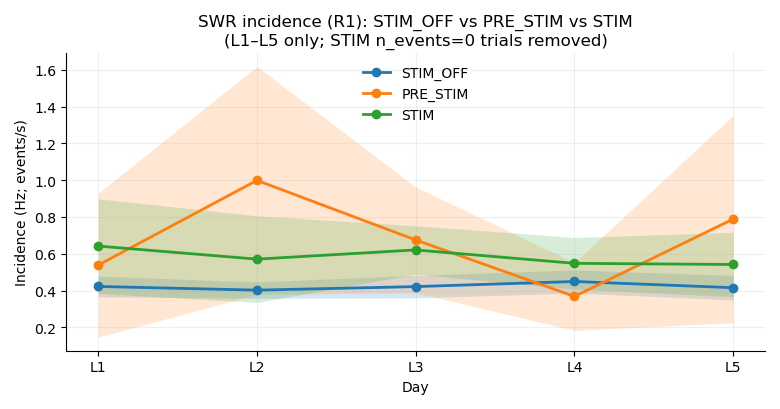


SWR mean duration (R1): STIM_OFF vs PRE_STIM vs STIM
(L1–L5 only; STIM n_events=0 trials removed)
Trials included per day (summed across animals):
  STIM_OFF: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84
  PRE_STIM: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84
  STIM: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84


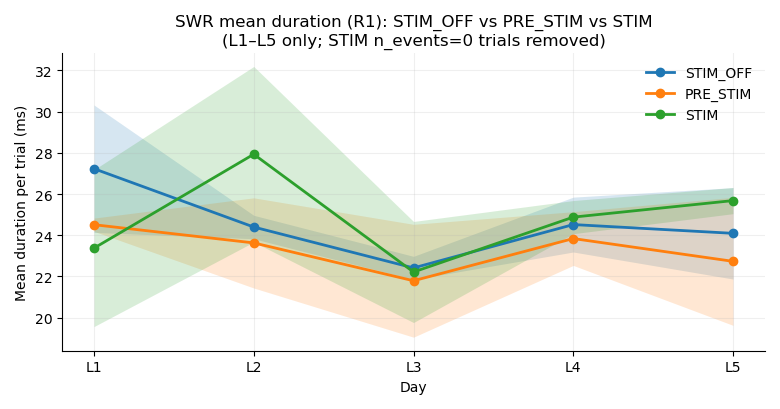


SWR peak frequency (R1): STIM_OFF vs PRE_STIM vs STIM
(L1–L5 only; STIM n_events=0 trials removed)
Trials included per day (summed across animals):
  STIM_OFF: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84
  PRE_STIM: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84
  STIM: L1:12, L2:16, L3:19, L4:15, L5:22 | TOTAL=84


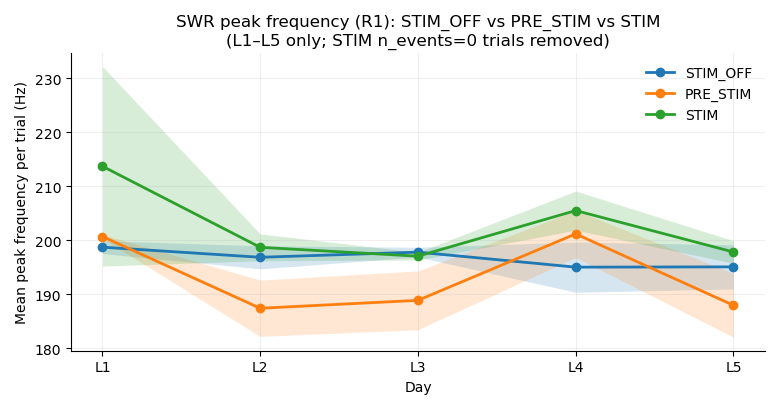

In [67]:
# ============================================================
# SWR day-by-day (R1 only) across 3 animals:
#   - Learning days only: trial_type == 'L' (L1..L5)
#   - Compare STIM vs STIM_OFF vs PRE_STIM
#   - REMOVE TRIALS where STIM has n_events == 0 (drop that trial across ALL conditions)
#   - For each plot: print number of trials included
#   - Plot SEM as pale shaded band (mean ± SEM)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- REQUIRE df_trial_metrics ----
if "df_trial_metrics" not in globals() or df_trial_metrics is None or len(df_trial_metrics) == 0:
    raise RuntimeError("df_trial_metrics not found / empty. Run your batch SWR metrics first (with PRE_STIM included).")

df = df_trial_metrics.copy()

# ----------------------------
# Basic normalization
# ----------------------------
def _to_num(s):
    return pd.to_numeric(s, errors="coerce")

def _sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size <= 1:
        return np.nan
    return float(np.std(x, ddof=1) / np.sqrt(x.size))

df["id"] = df["id"].astype(str).str.strip().str.upper()
df["trial_type"] = df["trial_type"].astype(str).str.strip().str.upper()
df["condition"] = df["condition"].astype(str).str.strip().str.upper()
df["channel"] = df["channel"].astype(str).str.strip().str.upper()

df["trial_id_num"] = _to_num(df.get("trial_id"))
df["ses_num"] = _to_num(df.get("ses"))

# Build an ordering key per animal/session:
if df["ses_num"].notna().any():
    df["order_key"] = df["ses_num"]
    ORDER_KEY_NAME = "ses_num"
else:
    if "date" not in df.columns:
        raise ValueError("No usable session ordering: need numeric 'ses' or a 'date' column.")
    df["order_key"] = pd.to_datetime(df["date"], errors="coerce")
    ORDER_KEY_NAME = "date"

# ----------------------------
# Filter to: R1, Learning only, STIM/STIM_OFF/PRE_STIM, valid trials 1..8
# ----------------------------
wanted_conds = ["STIM_OFF", "PRE_STIM", "STIM"]
df = df[
    (df["channel"] == "R1")
    & (df["trial_type"] == "L")                   # REMOVE TEST DAY here
    & (df["condition"].isin(wanted_conds))
    & (df["trial_id_num"].between(1, 8, inclusive="both"))
].copy()

if df.empty:
    raise RuntimeError(
        "After filtering to R1 + trial_type=='L' + trial_id 1..8 + conditions STIM_OFF/PRE_STIM/STIM, no rows remained.\n"
        "Check: trial_type labels, channel labels, condition labels, and that PRE_STIM exists in df_trial_metrics."
    )

# ----------------------------
# Build day labels: L1..L5 (per animal)
# ----------------------------
day_rows = []

for aid, dfa in df.groupby("id", sort=False):
    dfa = dfa.copy()
    dfa["day_label"] = pd.NA
    dfa["day_index"] = pd.NA

    # unique learning session keys in chronological order
    L_sess = (
        dfa[["order_key"]]
        .drop_duplicates()
        .sort_values("order_key")
        .reset_index(drop=True)
    )

    # first 5 learning days
    L_sess5 = L_sess.iloc[:5].copy()

    for i, ok in enumerate(L_sess5["order_key"].tolist(), start=1):
        m = (dfa["order_key"] == ok)
        dfa.loc[m, "day_label"] = f"L{i}"
        dfa.loc[m, "day_index"] = i

    dfa = dfa[dfa["day_label"].notna()].copy()
    day_rows.append(dfa)

df_use = pd.concat(day_rows, ignore_index=True) if len(day_rows) else pd.DataFrame()
if df_use.empty:
    raise RuntimeError(
        "No rows matched after labeling L1..L5. "
        "Check ses/date ordering and that you have learning sessions."
    )

df_use["day_index"] = pd.to_numeric(df_use["day_index"], errors="coerce")

# ----------------------------
# REQUIRED: drop trials where STIM has n_events == 0
#   trial key = (id, order_key, trial_id_num, trial_type)
# ----------------------------
if "n_events" not in df_use.columns:
    raise ValueError("df_trial_metrics must contain 'n_events' to apply the exclusion rule.")

stim_zero = df_use[
    (df_use["condition"] == "STIM") &
    (pd.to_numeric(df_use["n_events"], errors="coerce").fillna(0) == 0)
].copy()

trial_keys = ["id", "order_key", "trial_type", "trial_id_num"]
drop_keys = stim_zero[trial_keys].drop_duplicates()

before_n = len(df_use)
df_use = df_use.merge(drop_keys.assign(_drop=1), on=trial_keys, how="left")
df_use = df_use[df_use["_drop"].isna()].drop(columns=["_drop"])
after_n = len(df_use)

print(f"Dropped {before_n - after_n} rows total due to STIM n_events==0 rule "
      f"(trials dropped: {len(drop_keys)}).")

# ----------------------------
# Sanity check: trials per animal-day-condition AFTER dropping
# ----------------------------
trial_counts = (
    df_use.groupby(["id", "day_label", "condition"], dropna=False)
          .agg(n_trials=("trial_id_num", "nunique"))
          .reset_index()
          .sort_values(["id", "day_label", "condition"])
)
print("\nTrial counts per id/day/condition AFTER dropping (L-days may now be < 8):")
print(trial_counts.head(120))

# ----------------------------
# Verify required metrics exist
# ----------------------------
metrics = ["incidence_hz", "duration_mean_ms", "peak_freq_mean_hz"]
missing = [m for m in metrics if m not in df_use.columns]
if missing:
    raise ValueError(f"Missing expected metric columns in df_trial_metrics: {missing}")

# ----------------------------
# Aggregate per animal-day-condition (mean across remaining trials)
# ----------------------------
df_animal_day = (
    df_use.groupby(["id", "day_index", "day_label", "condition"], dropna=False)
          .agg(
              n_trials=("trial_id_num", "nunique"),
              incidence_hz_mean=("incidence_hz", "mean"),
              duration_mean_ms_mean=("duration_mean_ms", "mean"),
              peak_freq_mean_hz_mean=("peak_freq_mean_hz", "mean"),
          )
          .reset_index()
          .sort_values(["id", "day_index", "condition"])
)

# ----------------------------
# Group across animals: mean ± SEM for plotting
# each animal-day is one unit
# ----------------------------
df_group = (
    df_animal_day.groupby(["day_index", "day_label", "condition"], dropna=False)
        .agg(
            n_animal=("id", "nunique"),
            n_trials_mean=("n_trials", "mean"),
            n_trials_sum=("n_trials", "sum"),   # total trials contributing across animals

            incidence_hz=("incidence_hz_mean", "mean"),
            incidence_sem=("incidence_hz_mean", _sem),

            duration_ms=("duration_mean_ms_mean", "mean"),
            duration_sem=("duration_mean_ms_mean", _sem),

            peak_hz=("peak_freq_mean_hz_mean", "mean"),
            peak_sem=("peak_freq_mean_hz_mean", _sem),
        )
        .reset_index()
        .sort_values(["day_index", "condition"])
)

print(f"\nSession ordering key used: {ORDER_KEY_NAME}")
print("\nAnimal-day summary (R1) AFTER dropping STIM-zero trials:")
display(df_animal_day)

print("\nAcross-animals day summary (mean±SEM) AFTER dropping STIM-zero trials:")
display(df_group)

# ----------------------------
# Plot helper:
#   - shaded SEM band (mean ± SEM)
#   - print number of trials included per condition (per day + total)
# ----------------------------
def plot_day_comparison(df_group, ycol, yerr, title, ylabel):
    order = ["L1", "L2", "L3", "L4", "L5"]
    x_map = {lab: i for i, lab in enumerate(order, start=1)}

    fig, ax = plt.subplots(figsize=(7.8, 4.1))

    # PRINT trial counts used in THIS plot (from df_group n_trials_sum)
    print("\n" + "=" * 80)
    print(title)
    print("Trials included per day (summed across animals):")
    for cond in ["STIM_OFF", "PRE_STIM", "STIM"]:
        dcnt = df_group[df_group["condition"] == cond].copy()
        dcnt = dcnt[dcnt["day_label"].isin(order)].copy()
        dcnt = dcnt.sort_values("day_index")
        if dcnt.empty:
            print(f"  {cond}: (no data)")
            continue
        per_day = ", ".join([f"{dl}:{int(n)}" for dl, n in zip(dcnt["day_label"], dcnt["n_trials_sum"])])
        total = int(np.nansum(dcnt["n_trials_sum"].values))
        print(f"  {cond}: {per_day} | TOTAL={total}")

    # plot with shaded SEM
    for cond in ["STIM_OFF", "PRE_STIM", "STIM"]:
        d = df_group[df_group["condition"] == cond].copy()
        d = d[d["day_label"].isin(order)].copy()
        d["x"] = d["day_label"].map(x_map)
        d = d.dropna(subset=["x"]).sort_values("x")
        if d.empty:
            continue

        x = d["x"].values.astype(float)
        y = d[ycol].values.astype(float)
        se = d[yerr].values.astype(float)

        (ln,) = ax.plot(x, y, marker="o", linewidth=2, label=cond)
        # use the SAME color as the line, but pale
        ax.fill_between(x, y - se, y + se, alpha=0.18, color=ln.get_color(), linewidth=0)

    ax.set_xticks(list(x_map.values()))
    ax.set_xticklabels(order)
    ax.set_title(title)
    ax.set_xlabel("Day")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

# ----------------------------
# Make the 3 requested plots (Learning days only)
# ----------------------------
plot_day_comparison(
    df_group,
    ycol="incidence_hz",
    yerr="incidence_sem",
    title="SWR incidence (R1): STIM_OFF vs PRE_STIM vs STIM\n(L1–L5 only; STIM n_events=0 trials removed)",
    ylabel="Incidence (Hz; events/s)"
)

plot_day_comparison(
    df_group,
    ycol="duration_ms",
    yerr="duration_sem",
    title="SWR mean duration (R1): STIM_OFF vs PRE_STIM vs STIM\n(L1–L5 only; STIM n_events=0 trials removed)",
    ylabel="Mean duration per trial (ms)"
)

plot_day_comparison(
    df_group,
    ycol="peak_hz",
    yerr="peak_sem",
    title="SWR peak frequency (R1): STIM_OFF vs PRE_STIM vs STIM\n(L1–L5 only; STIM n_events=0 trials removed)",
    ylabel="Mean peak frequency per trial (Hz)"
)

In [56]:
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

def events_to_mask(events, n):
    m = np.zeros(n, dtype=bool)
    if events is None or len(events) == 0:
        return m
    for s, e in np.asarray(events, dtype=int):
        s = max(0, s)
        e = min(n, e)
        if e > s:
            m[s:e] = True
    return m

def compare_swr_detections_viewer(
    lfp_data, fs, stim_trains,
    pair_right=(9, 15), pair_left=(25, 27),
    results=None,
    hemi="RIGHT",
    start_s=0.0, window_s=10.0,
    ttl_pad_s=1.0,
    ylim_raw=None, ylim_bp=None,
):
    assert results is not None, "Pass the `results` dict produced by your detection step."
    n = lfp_data.shape[0]

    ch1, ch2 = pair_right if hemi.upper() == "RIGHT" else pair_left
    x = np.asarray(lfp_data[:, ch1] - lfp_data[:, ch2], dtype=np.float32)

    j = results[hemi]["Jadhav"]
    k = results[hemi]["Kuga"]
    x_bp = j.get("bandpassed", k.get("bandpassed", np.zeros_like(x)))

    env, thr_j = j["env"], float(j["threshold"])
    rms, thr_k = k["rms"], float(k["threshold"])
    ev_j = np.asarray(j["events"]) if len(j["events"]) else np.empty((0, 2), dtype=int)
    ev_k = np.asarray(k["events"]) if len(k["events"]) else np.empty((0, 2), dtype=int)

    ttl_pad = int(round(ttl_pad_s * fs))
    ttl_spans = []
    for s, e in np.asarray(stim_trains, dtype=int):
        s0 = max(0, int(s) - ttl_pad)
        e0 = min(n, int(e) + ttl_pad)
        ttl_spans.append((s0, e0))

    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    plt.subplots_adjust(bottom=0.14, hspace=0.25)

    ax_sl = fig.add_axes([0.12, 0.05, 0.76, 0.035])
    max_start = max(0.0, (n / fs) - window_s)
    sld = Slider(ax_sl, "Start (s)", 0.0, max_start, valinit=start_s)

    def shade_ttl(ax, i0, i1):
        for s0, e0 in ttl_spans:
            if e0 <= i0 or s0 >= i1:
                continue
            ax.axvspan(max(s0, i0) / fs, min(e0, i1) / fs, alpha=0.08)

    def shade_events(ax, i0, i1, events, label, alpha=0.15):
        first = True
        for s, e in events:
            if e <= i0 or s >= i1:
                continue
            ax.axvspan(max(s, i0) / fs, min(e, i1) / fs, alpha=alpha, label=(label if first else None))
            first = False

    def render(s0):
        i0 = int(s0 * fs)
        i1 = min(int((s0 + window_s) * fs), n)
        t = np.arange(i0, i1) / fs

        for ax in axes:
            ax.clear()

        axes[0].plot(t, x[i0:i1], lw=0.7)
        shade_ttl(axes[0], i0, i1)
        axes[0].set_ylabel("Bipolar (a.u.)")
        axes[0].set_title(f"{hemi} bipolar ch{ch1}-ch{ch2} | window={window_s}s")
        if ylim_raw is not None:
            axes[0].set_ylim(*ylim_raw)
        axes[0].grid(True, alpha=0.2)

        axes[1].plot(t, x_bp[i0:i1], lw=0.7)
        shade_ttl(axes[1], i0, i1)
        axes[1].set_ylabel("150-250 Hz")
        if ylim_bp is not None:
            axes[1].set_ylim(*ylim_bp)
        axes[1].grid(True, alpha=0.2)

        axes[2].plot(t, env[i0:i1], lw=0.8)
        axes[2].axhline(thr_j, ls="--", lw=0.8)
        shade_events(axes[2], i0, i1, ev_j, "Jadhav events", alpha=0.18)
        shade_ttl(axes[2], i0, i1)
        axes[2].set_ylabel("Env (J)")
        axes[2].grid(True, alpha=0.2)
        axes[2].legend(loc="upper right")

        axes[3].plot(t, rms[i0:i1], lw=0.8)
        axes[3].axhline(thr_k, ls="--", lw=0.8)
        shade_events(axes[3], i0, i1, ev_k, "Kuga events", alpha=0.18)
        shade_ttl(axes[3], i0, i1)
        axes[3].set_ylabel("RMS (K)")
        axes[3].set_xlabel("Time (s)")
        axes[3].grid(True, alpha=0.2)
        axes[3].legend(loc="upper right")

        axes[3].set_xlim(s0, s0 + window_s)
        fig.canvas.draw_idle()

    sld.on_changed(lambda v: render(sld.val))
    render(start_s)
    plt.show()

lfp_view = np.asarray(globals().get("lfp_raw", globals().get("lfp_ds")), dtype=np.float32)
fs_view = float(globals().get("fs", globals().get("fs_ds", 2000.0)))
trains_view = np.asarray(globals().get("stim_trains_raw", globals().get("pulses_ds", np.zeros((0, 2), dtype=np.int64))), dtype=np.int64)

compare_swr_detections_viewer(
    lfp_view, fs_view, trains_view,
    pair_right=(9, 15), pair_left=(25, 27),
    results=results, hemi="RIGHT", start_s=0.0, window_s=10.0, ttl_pad_s=1.0,
)

compare_swr_detections_viewer(
    lfp_view, fs_view, trains_view,
    pair_right=(9, 15), pair_left=(25, 27),
    results=results, hemi="LEFT", start_s=0.0, window_s=10.0, ttl_pad_s=1.0,
)



NameError: name 'results' is not defined

In [59]:
# ============================================================
# Average SWR incidence by day (learning trials, STIM only),
# per animal and channel R1-R4, using trial_id 1..8.
# Highlight highest-incidence channel for each animal-day.
# ============================================================

import numpy as np
import pandas as pd

# ---- REQUIRE df_trial_metrics ----
if "df_trial_metrics" not in globals() or df_trial_metrics is None:
    raise RuntimeError("df_trial_metrics not found. Run the batch Jadhav metrics code first.")

dfi = df_trial_metrics.copy()

# ----------------------------
# Helpers
# ----------------------------
def _to_num(x):
    return pd.to_numeric(x, errors="coerce")

def _is_learning(df):
    # Prefer explicit boolean if you already made it
    if "is_learning" in df.columns:
        return df["is_learning"].fillna(False).astype(bool)
    # Otherwise, use trial_type == L
    if "trial_type" in df.columns:
        return df["trial_type"].astype(str).str.upper().eq("L")
    if "trial_type_day" in df.columns:
        return df["trial_type_day"].astype(str).str.upper().eq("L")
    raise ValueError("No learning indicator found. Need is_learning or trial_type/trial_type_day.")

def _find_day_key(df):
    # Your “day” can be session index or date
    for k in ["ses", "session", "day", "date"]:
        if k in df.columns:
            return k
    raise ValueError("No day/session column found. Expected one of: ses/session/day/date.")

def _sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size <= 1:
        return np.nan
    return float(np.std(x, ddof=1) / np.sqrt(x.size))

# ----------------------------
# Normalize / filter rows
# ----------------------------
dfi["trial_id_num"] = _to_num(dfi.get("trial_id"))

day_key = _find_day_key(dfi)

# Learning + STIM + R1-R4 + trial_id 1..8
dfi = dfi[
    _is_learning(dfi)
    & (dfi["condition"].astype(str).str.upper() == "STIM")
    & (dfi["channel"].isin(["R1"]))
    & (dfi["trial_id_num"].between(1, 8, inclusive="both"))
].copy()

# ----------------------------
# Aggregate: animal x day x channel
# ----------------------------
group_cols = ["id", day_key, "channel"]
if "trial_type_day" in dfi.columns:
    group_cols.insert(2, "trial_type_day")  # keep this if you use it

df_day_inc = (
    dfi.groupby(group_cols, dropna=False)
      .agg(
          n_trials=("trial_id_num", "nunique"),
          avg_incidence_hz=("incidence_hz", "mean"),
          sem_incidence_hz=("incidence_hz", _sem),
      )
      .reset_index()
      .sort_values(group_cols)
)

# Option A: enforce exactly 8 trials per day (recommended for your design)
df_day_inc_8 = df_day_inc[df_day_inc["n_trials"] == 8].copy()

# Use strict if it exists, else fallback
df_day_use = df_day_inc_8 if len(df_day_inc_8) else df_day_inc.copy()

# ----------------------------
# Highlight highest channel per animal-day
# ----------------------------
max_group = ["id", day_key]
if "trial_type_day" in df_day_use.columns:
    max_group.insert(2, "trial_type_day")

df_day_use["highest_incidence_hz_day"] = df_day_use.groupby(max_group)["avg_incidence_hz"].transform("max")
df_day_use["is_highest_channel"] = df_day_use["avg_incidence_hz"].eq(df_day_use["highest_incidence_hz_day"])

# ----------------------------
# Wide view: one row per animal-day, columns R1..R4
# ----------------------------
pivot_index = ["id", day_key]
if "trial_type_day" in df_day_use.columns:
    pivot_index.append("trial_type_day")

pivot_inc = (
    df_day_use.pivot_table(
        index=pivot_index,
        columns="channel",
        values="avg_incidence_hz",
        aggfunc="mean"
    )
    .reset_index()
    .sort_values(pivot_index)
)

chan_cols = [c for c in ["R1", "R2", "R3", "R4"] if c in pivot_inc.columns]
if chan_cols:
    pivot_inc["highest_channel"] = pivot_inc[chan_cols].idxmax(axis=1)
    pivot_inc["highest_incidence_hz"] = pivot_inc[chan_cols].max(axis=1)

print(f"Day key used: {day_key}")
print("Rows used:", len(df_day_use), "| strict 8-trial rows:", len(df_day_inc_8))

display(df_day_use)   # long format with highlight flag
display(pivot_inc)    # wide format with highest channel per day

# (Optional) UI tables if available
try:
    from caas_jupyter_tools import display_dataframe_to_user
    display_dataframe_to_user("SWR incidence by day/channel (STIM, learning) — long", df_day_use)
    display_dataframe_to_user("SWR incidence by day (R1–R4) — wide", pivot_inc)
except Exception:
    pass

Day key used: ses
Rows used: 12 | strict 8-trial rows: 12


,id,ses,trial_type_day,channel,n_trials,avg_incidence_hz,sem_incidence_hz,highest_incidence_hz_day,is_highest_channel
0,AM,4,1,R1,8,0.024519,0.024519,0.024519,True
1,AM,5,2,R1,8,0.314443,0.097209,0.314443,True
2,AM,6,3,R1,8,0.454811,0.054136,0.454811,True
3,AM,7,4,R1,8,0.276616,0.252203,0.276616,True
6,AN,30,2,R1,8,0.854509,0.150540,0.854509,True
7,AN,31,3,R1,8,0.820577,0.108961,0.820577,True
9,AN,33,5,R1,8,0.701508,0.100686,0.701508,True
10,AO,29,1,R1,8,0.561433,0.294240,0.561433,True
11,AO,30,2,R1,8,0.053953,0.042170,0.053953,True
12,AO,31,3,R1,8,0.585957,0.065499,0.585957,True


channel,id,ses,trial_type_day,R1,highest_channel,highest_incidence_hz
0,AM,4,1,0.024519,R1,0.024519
1,AM,5,2,0.314443,R1,0.314443
2,AM,6,3,0.454811,R1,0.454811
3,AM,7,4,0.276616,R1,0.276616
4,AN,30,2,0.854509,R1,0.854509
5,AN,31,3,0.820577,R1,0.820577
6,AN,33,5,0.701508,R1,0.701508
7,AO,29,1,0.561433,R1,0.561433
8,AO,30,2,0.053953,R1,0.053953
9,AO,31,3,0.585957,R1,0.585957


# Band pass filter
        SWR: 120-200 Hz

## Continuous Wavelet Transform and projection calculation

First on signal with no wake time to determine sd of signal

In [ ]:
# Parameter and computation of CWT
w = 10.
freq = np.linspace(120, 200, 80)
widths = w*fs / (2*freq*np.pi)
CA1NWcwt = signal.cwt(filt_CA1wakeremoved, signal.morlet2, widths, w=w)

# Projection calculation
absCA1NWcwt = np.absolute(CA1NWcwt)
proj_CA1NWcwt = np.sum(absCA1NWcwt, axis = 0)/80
sdproj_CA1cwt = np.std(proj_CA1NWcwt)
sd3proj_CA1cwt = sdproj_CA1cwt*3
sd10proj_CA1cwt = sdproj_CA1cwt*10
sd8proj_CA1cwt = sdproj_CA1cwt*8
sd7proj_CA1cwt = sdproj_CA1cwt*7
sd05proj_CA1cwt = sdproj_CA1cwt*0.5

Second on the signal for which wake times have been zeroed

In [ ]:
# Conservative boolean filtering of CA1 filtered signal
BooleanCons = EMGboolean['BooleanConservative']
fCA1wake0C = filt_CA1.copy()
fCA1wake0C[BooleanCons] = 0
CA1wake0C = CA1.copy()
CA1wake0C[BooleanCons] = 0
# Liberal boolean filtering of CA1 filtered signal
BooleanLib = EMGboolean['BooleanLiberal']
fCA1wake0L = filt_CA1.copy()
fCA1wake0L[BooleanLib] = 0
CA1wake0L = CA1.copy()
CA1wake0L[BooleanLib] = 0

# Computation of CWT
CA1cwtWake0cons = signal.cwt(fCA1wake0C, signal.morlet2, widths, w=w)
CA1cwtWake0lib = signal.cwt(fCA1wake0L, signal.morlet2, widths, w=w)

# Projection calculation
absCA1W0Ccwt = np.absolute(CA1cwtWake0cons)
proj_CA1W0Ccwt = np.sum(absCA1W0Ccwt, axis = 0)/80
absCA1W0Lcwt = np.absolute(CA1cwtWake0lib)
proj_CA1W0Lcwt = np.sum(absCA1W0Lcwt, axis = 0)/80

combined = np.stack([CA1, filt_CA1, proj_CA1W0Ccwt, proj_CA1W0Lcwt], axis = 1)

sample_rate = 1000.
t_start = 0.

## Extracting SWRs and determining main properties 

First extraction of SWR peaks, initiation, end and width

In [ ]:
# 3 sd threshold
peaks, properties = find_peaks(proj_CA1W0Lcwt, prominence=1, width=20, height=sd3proj_CA1cwt)
properties["prominences"], properties["widths"]

# SWR boundaries taken at 70% from peak of intensity. This means that the SWRs with small amplitude will be longer than the big ones.
results_width = peak_widths(proj_CA1W0Lcwt, peaks, rel_height=0.7)

# Organise results in numpy array
peaks2 = peaks.reshape(len(peaks),1)
npresults_width = np.array(results_width).reshape(4,-1)
SWR_prop = np.append(peaks2, results_width).reshape(5,len(peaks2)).round()

Display subset

Second extraction of main frequency and power 

In [ ]:
projMaxP_cwtmg = np.max(CA1cwtWake0lib, axis = 0)
projMaxF_cwtmg = np.argmax(CA1cwtWake0lib, axis = 0) + 120
projMaxP_cwtmg.shape

nb_SWR = len(peaks)
data = np.zeros((nb_SWR,4))

for tt in np.arange(nb_SWR):
    SWR_start = int(SWR_prop[3,tt])
    SWR_stop = int(SWR_prop[4,tt])
    SWR_MaxP = projMaxP_cwtmg[SWR_start:SWR_stop]
    SWR_MaxF = projMaxF_cwtmg[SWR_start:SWR_stop]
    data[tt, 0] = max(SWR_MaxF).round()
    data[tt, 1] = max(SWR_MaxP).round()
    data[tt, 2] = round(sum(SWR_MaxF)/len(SWR_MaxF))
    data[tt, 3] = round(sum(SWR_MaxP)/len(SWR_MaxP))

param_SWR = pd.DataFrame(data, columns = ['Max freq', 'Max int', 'Avg freq', 'Avg int'])
tSWR_prop = SWR_prop.transpose()
pd_prop_SWR = pd.DataFrame(tSWR_prop, columns = ['peak time', 'Duration', 'peak amp', 'start time', 'end time'])
pd_tokeep = pd.DataFrame(np.ones(nb_SWR).astype(bool), columns = ['toKeep'])
All_SWR = pd.concat([pd_tokeep,pd_prop_SWR, param_SWR], axis=1)

SWR_peak = peaks
SWR_start = SWR_prop[3,:].astype(int)
SWR_end = SWR_prop[4,:].astype(int)

### Store the results in All_SWR_prop pd dataframe and save as pkl/csv for post processing.

End of Notebook. 

In [ ]:
filename2 = os.path.join(dpath,f'SWRproperties{suffix}.pkl')
filename3 = os.path.join(dpath,f'SWRproperties{suffix}.csv')
All_SWR.to_pickle(filename2)
All_SWR.to_csv(filename3, sep = ',')

combined = np.stack([CA1, filt_CA1, proj_CA1W0Ccwt, proj_CA1W0Lcwt], axis = 1)
filenameC = os.path.join(dpath,f'SignalCA1.npy')
np.save(filenameC, combined)

sample_rate = 1000.
t_start = 0.
# if done and no intention to display for assessment
#%reset
#plt.close('all')

### Display and asses SWRs

#### ephys viewer to check SWR detection

In [ ]:
%%capture
%gui qt

app = mkQApp()

#Create one data source with 3 event channel
all_events = []
conditions = ['All','Good','Bad']
for c,cond in enumerate(conditions):
    match cond:
        case 'All':
            selection = "All_SWR['toKeep'] | ~All_SWR['toKeep']"
        case 'Good':
            selection = "All_SWR['toKeep']"
        case 'Bad':
            selection = "~All_SWR['toKeep']"
    ev_times = All_SWR.loc[pd.eval(selection),'peak time'].values/1000
    ev_labels = [f'SWR {i}'for i in All_SWR[pd.eval(selection)].index]
    all_events.append({ 'time':ev_times, 'label':ev_labels, 'name': conditions[c] })
source_ev = InMemoryEventSource(all_events=all_events)

combined = np.stack([CA1, fCA1wake0C, proj_CA1W0Lcwt, proj_CA1W0Ccwt, TTL], axis = 1)

sample_rate = 1000.
t_start = 0.

#create 2 familly scatters from theses 2 indexes
scatter_indexes = {0: SWR_peak, 1: SWR_start, 2: SWR_end}
#and asign them to some channels each
scatter_channels = {0: [1, 2], 1: [0, 1], 2: [0, 1]}
source = AnalogSignalSourceWithScatter(combined, sample_rate, t_start, scatter_indexes, scatter_channels)

#Create the main window that can contain several viewers
win = MainViewer(debug=True, show_auto_scale=True)

#create a viewer for signal with TraceViewer
#connected to the signal source
view1 = TraceViewer(source=source)

#Parameters can be set in script
view1.params['scale_mode'] = 'same_for_all'
view1.params['display_labels'] = True
view1.auto_scale()

nCh = len(view1.by_channel_params.children())
mult = 5
for ch in range(nCh):
    match ch%mult:
        case 0: # raw traces
            view1.by_channel_params[f'ch{ch}', 'offset'] = 2.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.05
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ffffff'
        case 1: # filtered traces
            view1.by_channel_params[f'ch{ch}', 'offset'] = 0.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#0055ff'
        case 2: # envelop
            view1.by_channel_params[f'ch{ch}', 'offset'] = 0.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ff5500'
        case 3: # envelop
            view1.by_channel_params[f'ch{ch}', 'offset'] = 0.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ffffff'
        case 4: # TTL
            view1.by_channel_params[f'ch{ch}', 'offset'] = 4.5 + 5*int(ch/mult)
            #view1.by_channel_params[f'ch{ch}', 'gain'] = 0.1
            view1.by_channel_params[f'ch{ch}', 'color'] = '#ffffff'
view1.params['ylim_max']=5*int((nCh+1)/mult)
view1.params['ylim_min']=0

view2 = EventList(source=source_ev, name='event')


#put this viewer in the main window
win.add_view(view1)
win.add_view(view2, location='bottom',  orientation='horizontal')

#Run
win.show()

#### Select and deselect SWRs

In [ ]:
def clicked(arg):
    selectedEvent = view2.list_widget.currentItem().text()
    selectedSWR = int(selectedEvent.split('SWR')[1])
    #print(selectedSWR)
    match arg.description:
        case 'Keep SWR':
            All_SWR.loc[selectedSWR,'toKeep']=True
            print(f'SWR {selectedSWR} restored')
        case 'Discard SWR':
            All_SWR.loc[selectedSWR,'toKeep']=False
            print(f'SWR {selectedSWR} discarded')
    #save modif
    All_SWR.to_pickle(filename2)
    All_SWR.to_csv(filename3, sep = ',')
    #Create one data source with 3 event channel
    all_events = []
    conditions = ['All','Good','Bad']
    for c,cond in enumerate(conditions):
        match cond:
            case 'All':
                selection = "All_SWR['toKeep'] | ~All_SWR['toKeep']"
            case 'Good':
                selection = "All_SWR['toKeep']"
            case 'Bad':
                selection = "~All_SWR['toKeep']"
        ev_times = All_SWR.loc[pd.eval(selection),'peak time'].values/1000
        ev_labels = [f'SWR {i}'for i in All_SWR[pd.eval(selection)].index]
        all_events.append({ 'time':ev_times, 'label':ev_labels, 'name': conditions[c] })
    source_ev = InMemoryEventSource(all_events=all_events)
    view2.source = source_ev
    view2.refresh_list(view2.combo.currentIndex())

button_Good = widgets.Button(description = 'Keep SWR')   
button_Good.on_click(clicked)

button_Bad = widgets.Button(description = 'Discard SWR')   
button_Bad.on_click(clicked)

display(button_Good, button_Bad)



In [ ]:
# plotting the points
plt.scatter(np.zeros(len(MaxSWR)), MaxSWR)
plt.scatter(np.ones(len(AvgSWR)), AvgSWR)


In [ ]:
# plotting the lines
for i in range(len(MaxSWR)):
    plt.plot( [0,1], [MaxSWR[i], AvgSWR[i]], c='k')
